# Chilean Glacier Analysis: Multi-Dataset Comparison
## All Clusters — Mass Balance and Runoff Analysis

**Datasets:** CR2MET, ERA5, CRU (2000-2019)  
**Reference:** Hugonnet et al. (2021) geodetic observations  
**SMB method:** Directly from mb.csv (OGGM calibrated output), area-weighted per cluster  
**GMB method:** Hugonnet area-weighted, matched to same glaciers as each simulation

In [16]:
import xarray as xr
import numpy as np
import pandas as pd
import os

# Filename pattern differs per dataset
NC_PATTERNS = {
    'CR2MET': 'run_output_2000_2019_hydro_TC_{cluster}.nc',
    'ERA5':   'run_output_2000_2019_hydro_ERA5_{cluster}.nc',
    'CRU':    'run_output_2000_2019_hydro_CRU_{cluster}.nc',
}
DATASETS = {
    'CR2MET': '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/CR2MET',
    'ERA5':   '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/ERA5',
    'CRU':    '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/CRU',
}
CLUSTERS = ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']
OUT_DIR_ALE = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/monthly_runoff_by_basin'
os.makedirs(OUT_DIR_ALE, exist_ok=True)

WATER_DENSITY = 1000  # kg/m³
YEARS  = list(range(2000, 2020))
MONTHS = list(range(1, 13))

for dataset_name, base_path in DATASETS.items():
    print(f"\n{'='*60}\nDataset: {dataset_name}\n{'='*60}")

    cluster_ds = {}
    for cluster in CLUSTERS:
        nc_file = NC_PATTERNS[dataset_name].format(cluster=cluster)
        nc_path = os.path.join(base_path, cluster, nc_file)
        if not os.path.exists(nc_path):
            print(f"  Missing: {nc_path}")
            continue
        cluster_ds[cluster] = xr.open_dataset(nc_path)

    if not cluster_ds:
        print(f"  No data found for {dataset_name}, skipping.")
        continue

    for gauge_id, info in GAUGE_INFO.items():
        rgi_ids    = info['rgi_ids']
        basin_name = RESULTS[gauge_id]['basin_name']

        rows = []
        for yr_idx, year in enumerate(YEARS):
            for mo_idx, month in enumerate(MONTHS):
                melt_total     = 0.0
                liq_prcp_total = 0.0

                for cluster, ds in cluster_ds.items():
                    rgi_all  = list(ds.rgi_id.values)
                    mask_ids = [r for r in rgi_ids if r in rgi_all]
                    if not mask_ids:
                        continue
                    mask = np.isin(rgi_all, mask_ids)

                    # kg → m³ by dividing by water density
                    melt_total     += np.nansum(
                        ds['melt_on_glacier_monthly'].values[yr_idx, mo_idx, mask]
                    ) / WATER_DENSITY
                    liq_prcp_total += np.nansum(
                        ds['liq_prcp_on_glacier_monthly'].values[yr_idx, mo_idx, mask]
                    ) / WATER_DENSITY

                rows.append({
                    'year':                    year,
                    'month':                   month,
                    'melt_on_glacier_m3':      melt_total,
                    'liq_prcp_on_glacier_m3':  liq_prcp_total,
                    'glacier_runoff_total_m3': melt_total + liq_prcp_total,
                })

        df = pd.DataFrame(rows)
        df['melt_on_glacier_km3']      = df['melt_on_glacier_m3']      / 1e9
        df['liq_prcp_on_glacier_km3']  = df['liq_prcp_on_glacier_m3']  / 1e9
        df['glacier_runoff_total_km3'] = df['glacier_runoff_total_m3']  / 1e9

        out_path = os.path.join(OUT_DIR_ALE,
                                f'glacier_runoff_{dataset_name}_{gauge_id}.csv')
        df.to_csv(out_path, index=False)
        print(f"  Saved: {os.path.basename(out_path)}  "
              f"({df['glacier_runoff_total_km3'].sum():.4f} km³ total)")

    for ds in cluster_ds.values():
        ds.close()

print(f"\nDone. All files saved to: {OUT_DIR_ALE}")


Dataset: CR2MET
  Saved: glacier_runoff_CR2MET_8304001.csv  (0.6159 km³ total)
  Saved: glacier_runoff_CR2MET_9122002.csv  (0.1871 km³ total)
  Saved: glacier_runoff_CR2MET_9123001.csv  (1.1144 km³ total)
  Saved: glacier_runoff_CR2MET_9402001.csv  (2.7667 km³ total)
  Saved: glacier_runoff_CR2MET_9412001.csv  (0.4871 km³ total)
  Saved: glacier_runoff_CR2MET_9414001.csv  (1.1846 km³ total)
  Saved: glacier_runoff_CR2MET_10102001.csv  (1.3085 km³ total)

Dataset: ERA5
  Saved: glacier_runoff_ERA5_8304001.csv  (0.4308 km³ total)
  Saved: glacier_runoff_ERA5_9122002.csv  (0.1428 km³ total)
  Saved: glacier_runoff_ERA5_9123001.csv  (0.7583 km³ total)
  Saved: glacier_runoff_ERA5_9402001.csv  (2.1266 km³ total)
  Saved: glacier_runoff_ERA5_9412001.csv  (0.2373 km³ total)
  Saved: glacier_runoff_ERA5_9414001.csv  (0.7579 km³ total)
  Saved: glacier_runoff_ERA5_10102001.csv  (0.9996 km³ total)

Dataset: CRU
  Saved: glacier_runoff_CRU_8304001.csv  (0.4076 km³ total)
  Saved: glacier_runoff_

In [21]:
import pandas as pd
import os

CAMELS_BASE = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS'
OUT_DIR_ALE = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/monthly_runoff_by_basin'

for gauge_id, info in GAUGE_INFO.items():
    basin_name = RESULTS[gauge_id]['basin_name']
    q_path = f'{CAMELS_BASE}/camels_cl_{gauge_id}/q_m3s_mon.csv'

    q = pd.read_csv(q_path, parse_dates=['date'])

    # Filter to 2000-2019, rename flow column, convert m³/s → m³/month
    q = q[(q['year'] >= 2000) & (q['year'] <= 2019)].copy()
    q = q.rename(columns={gauge_id: 'q_m3s'})
    q['days_in_month'] = pd.to_datetime(q['date']).dt.days_in_month
    q['q_m3_month'] = q['q_m3s'] * q['days_in_month'] * 86400
    q['q_km3_month'] = q['q_m3_month'] / 1e9

    # Keep clean output columns
    out = q[['date', 'year', 'month', 'q_m3s', 'q_m3_month', 'q_km3_month']].copy()
    out['basin_name'] = basin_name

    out_path = os.path.join(OUT_DIR_ALE, f'streamflow_{gauge_id}.csv')
    out.to_csv(out_path, index=False)

    n_valid = out['q_m3s'].notna().sum()
    total_q = out['q_km3_month'].sum()
    print(f"  Saved: streamflow_{gauge_id}.csv  "
          f"({n_valid}/240 months valid, {total_q:.3f} km³ total)")

print(f"\nDone. Streamflow CSVs saved to: {OUT_DIR_ALE}")

  Saved: streamflow_8304001.csv  (204/240 months valid, 14.349 km³ total)
  Saved: streamflow_9122002.csv  (208/240 months valid, 4.257 km³ total)
  Saved: streamflow_9123001.csv  (231/240 months valid, 50.465 km³ total)
  Saved: streamflow_9402001.csv  (207/240 months valid, 37.411 km³ total)
  Saved: streamflow_9412001.csv  (214/240 months valid, 15.213 km³ total)
  Saved: streamflow_9414001.csv  (220/240 months valid, 60.952 km³ total)
  Saved: streamflow_10102001.csv  (224/240 months valid, 23.988 km³ total)

Done. Streamflow CSVs saved to: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/monthly_runoff_by_basin


In [22]:
import zipfile
import os

OUT_DIR_ALE = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/monthly_runoff_by_basin'
zip_path = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/glacier_runoff_streamflow_araucania.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(os.listdir(OUT_DIR_ALE)):
        if f.endswith('.csv'):
            zf.write(os.path.join(OUT_DIR_ALE, f), arcname=f)
            print(f"  Added: {f}")

print(f"\nZip saved to: {zip_path}")

  Added: glacier_runoff_CR2MET_10102001.csv
  Added: glacier_runoff_CR2MET_8304001.csv
  Added: glacier_runoff_CR2MET_9122002.csv
  Added: glacier_runoff_CR2MET_9123001.csv
  Added: glacier_runoff_CR2MET_9402001.csv
  Added: glacier_runoff_CR2MET_9412001.csv
  Added: glacier_runoff_CR2MET_9414001.csv
  Added: glacier_runoff_CRU_10102001.csv
  Added: glacier_runoff_CRU_8304001.csv
  Added: glacier_runoff_CRU_9122002.csv
  Added: glacier_runoff_CRU_9123001.csv
  Added: glacier_runoff_CRU_9402001.csv
  Added: glacier_runoff_CRU_9412001.csv
  Added: glacier_runoff_CRU_9414001.csv
  Added: glacier_runoff_ERA5_10102001.csv
  Added: glacier_runoff_ERA5_8304001.csv
  Added: glacier_runoff_ERA5_9122002.csv
  Added: glacier_runoff_ERA5_9123001.csv
  Added: glacier_runoff_ERA5_9402001.csv
  Added: glacier_runoff_ERA5_9412001.csv
  Added: glacier_runoff_ERA5_9414001.csv
  Added: streamflow_10102001.csv
  Added: streamflow_8304001.csv
  Added: streamflow_9122002.csv
  Added: streamflow_9123001.csv


## code from before

KeyboardInterrupt: 

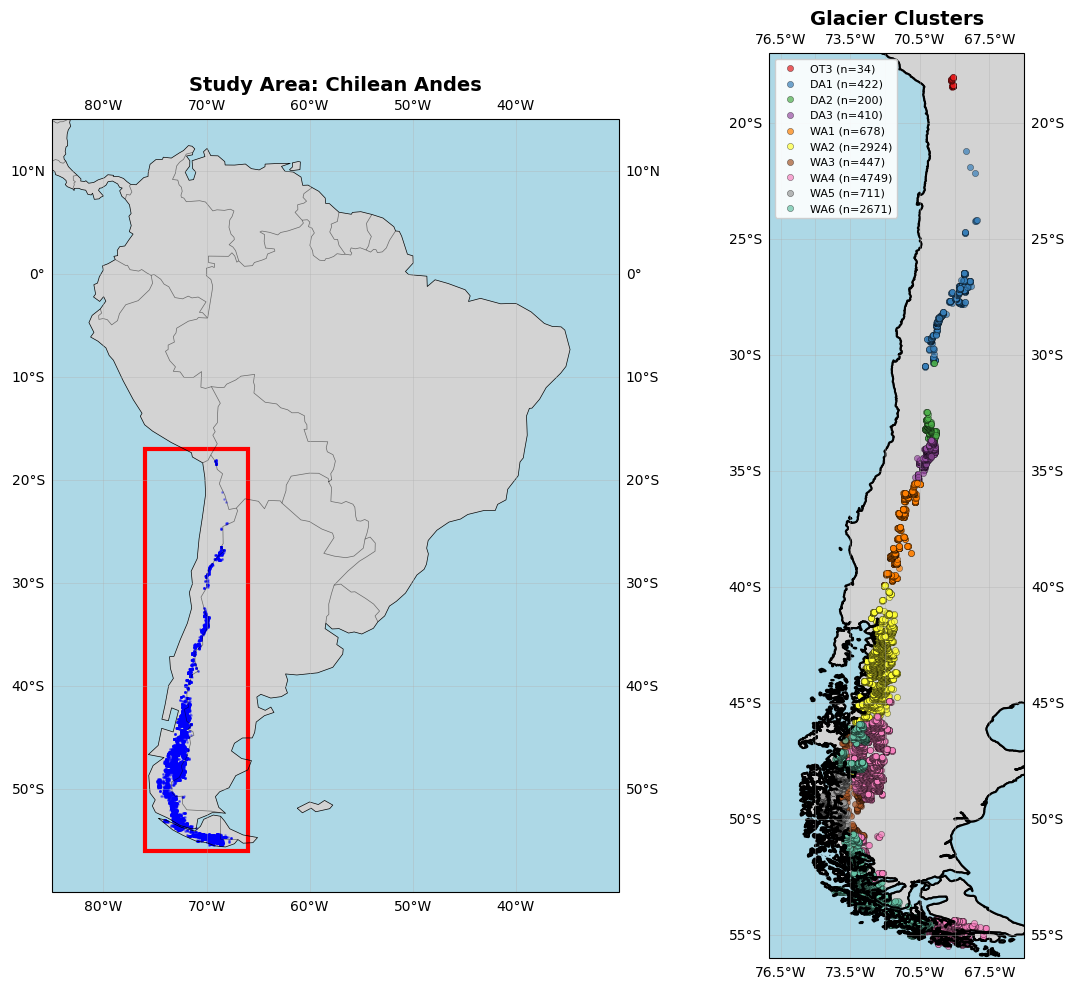

In [15]:
"""
Create study area map showing glacier clusters in Chile
"""

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load your cluster data
datos_rgi = pd.read_csv('/Users/milliespencer/Desktop/CR2_OGGM_Paper/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv')

# Create GeoDataFrame from your RGI data (assuming it has lat/lon columns)
# If your CSV has CenLat and CenLon:
gdf = gpd.GeoDataFrame(
    datos_rgi,
    geometry=gpd.points_from_xy(datos_rgi.CenLon, datos_rgi.CenLat),
    crs='EPSG:4326'
)

# Define cluster colors
cluster_colors = {
    'OT3': '#e41a1c',
    'DA1': '#377eb8',
    'DA2': '#4daf4a',
    'DA3': '#984ea3',
    'WA1': '#ff7f00',
    'WA2': '#ffff33',
    'WA3': '#a65628',
    'WA4': '#f781bf',
    'WA5': '#999999',
    'WA6': '#66c2a5'
}

# Create figure with two panels
fig = plt.figure(figsize=(12, 10))

# PANEL 1: South America context map
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.set_extent([-85, -30, -60, 15], crs=ccrs.PlateCarree())

# Add features
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none')
ax1.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)

# Highlight Chile
chile_bounds = [-76, -66, -56, -17]  # lon_min, lon_max, lat_min, lat_max
ax1.add_patch(Rectangle(
    xy=(chile_bounds[0], chile_bounds[2]),
    width=chile_bounds[1] - chile_bounds[0],
    height=chile_bounds[3] - chile_bounds[2],
    facecolor='none',
    edgecolor='red',
    linewidth=3,
    transform=ccrs.PlateCarree()
))

# Add all glaciers as small dots
ax1.scatter(gdf.CenLon, gdf.CenLat, s=1, c='blue', alpha=0.3, 
           transform=ccrs.PlateCarree(), label='Glaciers')

ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax1.set_title('Study Area: Chilean Andes', fontsize=14, fontweight='bold')

# PANEL 2: Chile detail with clusters
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.set_extent([-77, -66, -56, -17], crs=ccrs.PlateCarree())

# Add features
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=1.5)
ax2.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax2.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black')

# Plot each cluster with different colors
for cluster_name, color in cluster_colors.items():
    cluster_data = gdf[gdf['Cluster'] == cluster_name]
    if len(cluster_data) > 0:
        ax2.scatter(cluster_data.CenLon, cluster_data.CenLat, 
                   s=20, c=color, alpha=0.7, 
                   transform=ccrs.PlateCarree(),
                   label=f'{cluster_name} (n={len(cluster_data)})',
                   edgecolors='black', linewidths=0.3)

ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax2.set_title('Glacier Clusters', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Study_Area_Map.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Map saved to: Study_Area_Map.png")

## Glacier regions from Caro et al., 2021
https://www.frontiersin.org/journals/earth-science/articles/10.3389/feart.2021.713011/full

In [2]:
# ── Cell 1: Setup and imports ──────────────────────────────────────────────
import numpy as np
import xarray as xr
import seaborn as sns
from oggm import utils
import warnings
import os

if not hasattr(np, 'warnings'):
    np.warnings = warnings

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Use DejaVu Sans to avoid missing glyph warnings with superscripts
plt.rcParams['font.family'] = 'DejaVu Sans'

# Configuration
clusters = ['OT3', 'DA1', 'DA2', 'DA3', 'WA1', 'WA2', 'WA3', 'WA4', 'WA5', 'WA6']
datasets = ['CR2MET', 'CRU', 'ERA5']
base_path = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/'
rgi_path  = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'

colors = {'CR2MET': '#e74c3c', 'ERA5': '#3498db', 'CRU': '#2ecc71'}

print('✓ Setup complete')

/Users/milliespencer/miniconda3/envs/oggm_cr2_env/lib/python3.11/site-packages/oggm/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


✓ Setup complete


In [3]:
# ── Cell 2: Load geodetic reference + build glacier lists ──────────────────
geodetic_ref = utils.get_geodetic_mb_dataframe()
geodetic_ref = geodetic_ref[geodetic_ref['period'] == '2000-01-01_2020-01-01']

rgi_df = pd.read_csv(rgi_path)

glacier_lists = {}
for cluster in clusters:
    cluster_glaciers = rgi_df[rgi_df['Cluster'] == cluster]['RGIId'].tolist()
    glacier_lists[cluster] = {
        'all': cluster_glaciers,
        'with_gmb': [g for g in cluster_glaciers if g in geodetic_ref.index]
    }

print('GMB data availability by cluster:')
for cluster in clusters:
    n_all = len(glacier_lists[cluster]['all'])
    n_gmb = len(glacier_lists[cluster]['with_gmb'])
    print(f'  {cluster}: {n_gmb}/{n_all} glaciers have Hugonnet GMB ({n_gmb/n_all*100:.0f}%)')

print('\n✓ Geodetic reference and glacier lists ready')

GMB data availability by cluster:
  OT3: 34/34 glaciers have Hugonnet GMB (100%)
  DA1: 422/422 glaciers have Hugonnet GMB (100%)
  DA2: 200/200 glaciers have Hugonnet GMB (100%)
  DA3: 410/410 glaciers have Hugonnet GMB (100%)
  WA1: 678/678 glaciers have Hugonnet GMB (100%)
  WA2: 2924/2924 glaciers have Hugonnet GMB (100%)
  WA3: 447/447 glaciers have Hugonnet GMB (100%)
  WA4: 4749/4749 glaciers have Hugonnet GMB (100%)
  WA5: 711/711 glaciers have Hugonnet GMB (100%)
  WA6: 2671/2671 glaciers have Hugonnet GMB (100%)

✓ Geodetic reference and glacier lists ready


In [4]:
# ── Cell 3: Load SMB from mb.csv + compute area-weighted GMB ───────────────
#
# SMB is read directly from mb.csv (OGGM calibrated output, mm w.e. yr-1
# per glacier per year). Columns 0-19 = years 2000-2019 (matching Hugonnet).
# Only glaciers with Hugonnet GMB data and non-NaN mb.csv entries are used.
# N per dataset per cluster is tracked for figure labels.

def load_cluster_data(cluster, dataset):
    mb_file = f'{base_path}{dataset}/{cluster}/mb.csv'
    if not os.path.exists(mb_file):
        print(f'  Missing: {dataset}/{cluster}/mb.csv')
        return None

    mb_df = pd.read_csv(mb_file).set_index('rgi_id')
    glaciers_with_gmb = glacier_lists[cluster]['with_gmb']
    matched = [g for g in glaciers_with_gmb if g in mb_df.index]

    year_cols = mb_df.columns[:20]  # columns 0-19 = 2000-2019
    valid_mask = mb_df.loc[matched, year_cols].notna().all(axis=1)
    matched = [g for g in matched if valid_mask[g]]

    if len(matched) == 0:
        print(f'  WARNING: No valid glaciers for {dataset}/{cluster}')
        return None

    smb_per_glacier  = mb_df.loc[matched, year_cols].mean(axis=1)
    weights          = geodetic_ref.loc[matched, 'area']
    smb_weighted     = np.average(smb_per_glacier, weights=weights)
    gmb_weighted     = np.average(geodetic_ref.loc[matched, 'dmdtda'] * 1000, weights=weights)
    gmb_err_weighted = np.average(geodetic_ref.loc[matched, 'err_dmdtda'] * 1000, weights=weights)
    smb_std          = smb_per_glacier.std()

    return {
        'SMB': smb_weighted, 'GMB': gmb_weighted,
        'GMB_error': gmb_err_weighted, 'SMB_std': smb_std,
        'n_glaciers': len(matched)
    }

all_data = []
for cluster in clusters:
    for dataset in datasets:
        data = load_cluster_data(cluster, dataset)
        if data:
            all_data.append({
                'cluster':   cluster,
                'dataset':   dataset,
                'SMB':       data['SMB']       / 1000,
                'GMB':       data['GMB']       / 1000,
                'GMB_error': data['GMB_error'] / 1000,
                'SMB_std':   data['SMB_std']   / 1000,
                'bias':     (data['SMB'] - data['GMB']) / 1000,
                'n_glaciers': data['n_glaciers']
            })

df = pd.DataFrame(all_data)
print(f'✓ Loaded {len(df)} cluster-dataset combinations')
print(f'  Clusters: {df["cluster"].unique()}')
print(f'  Datasets: {df["dataset"].unique()}')
print('\nMean values per dataset:')
print(df.groupby('dataset')[['SMB', 'GMB', 'bias', 'n_glaciers']].mean().round(4))

✓ Loaded 30 cluster-dataset combinations
  Clusters: ['OT3' 'DA1' 'DA2' 'DA3' 'WA1' 'WA2' 'WA3' 'WA4' 'WA5' 'WA6']
  Datasets: ['CR2MET' 'CRU' 'ERA5']

Mean values per dataset:
            SMB     GMB  bias  n_glaciers
dataset                                  
CR2MET  -0.4543 -0.4543   0.0      1312.3
CRU     -0.4548 -0.4548   0.0      1309.9
ERA5    -0.4537 -0.4537   0.0      1316.0


Generating Option A...


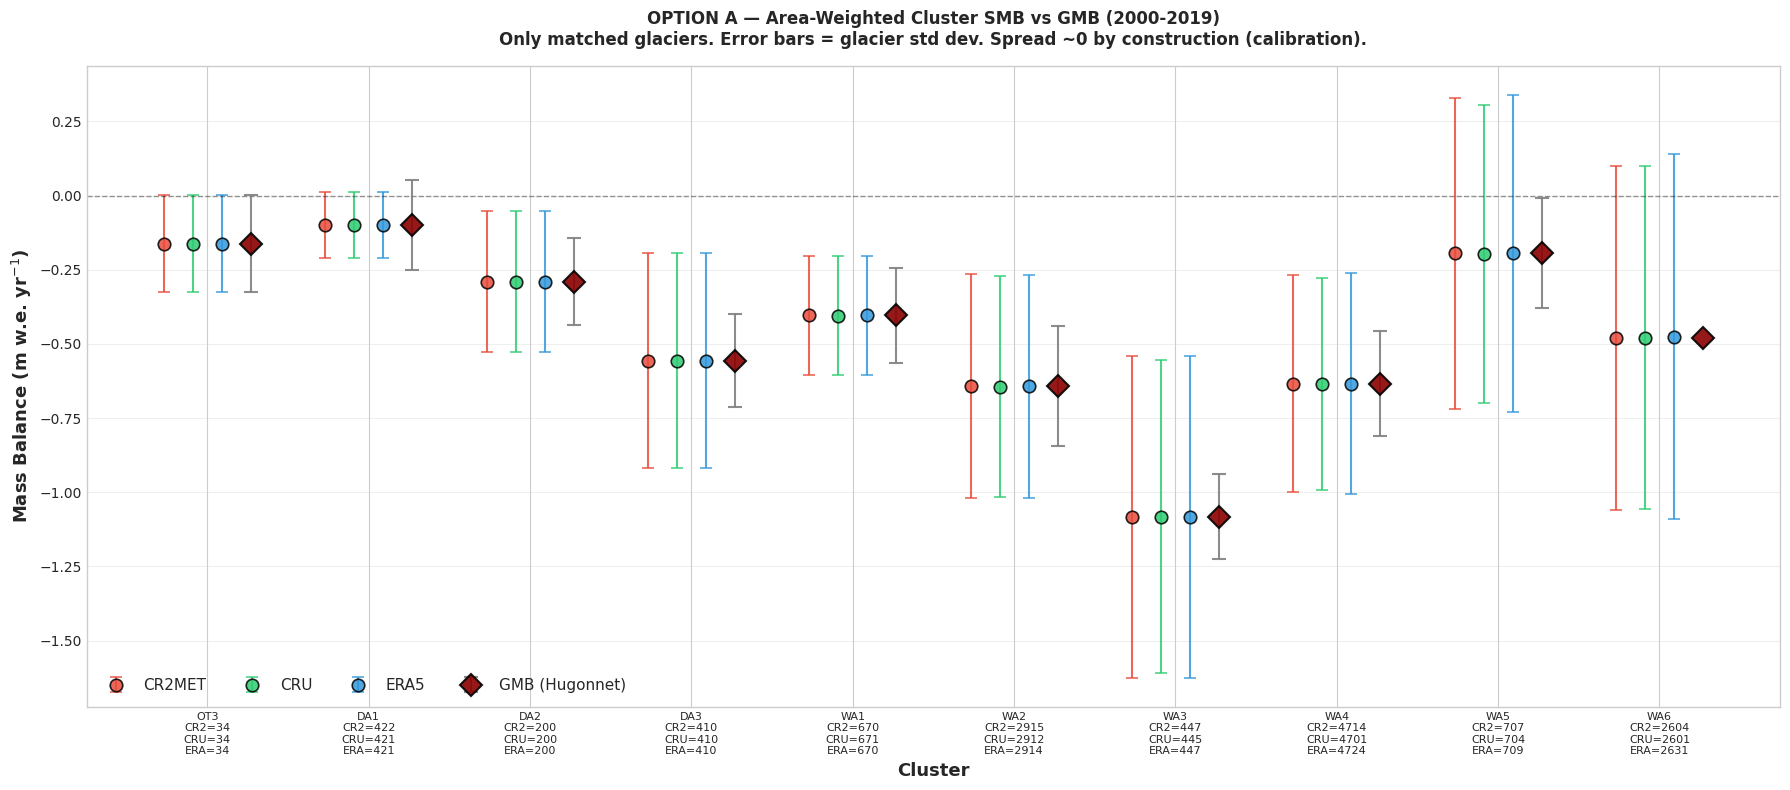

Generating Option B...


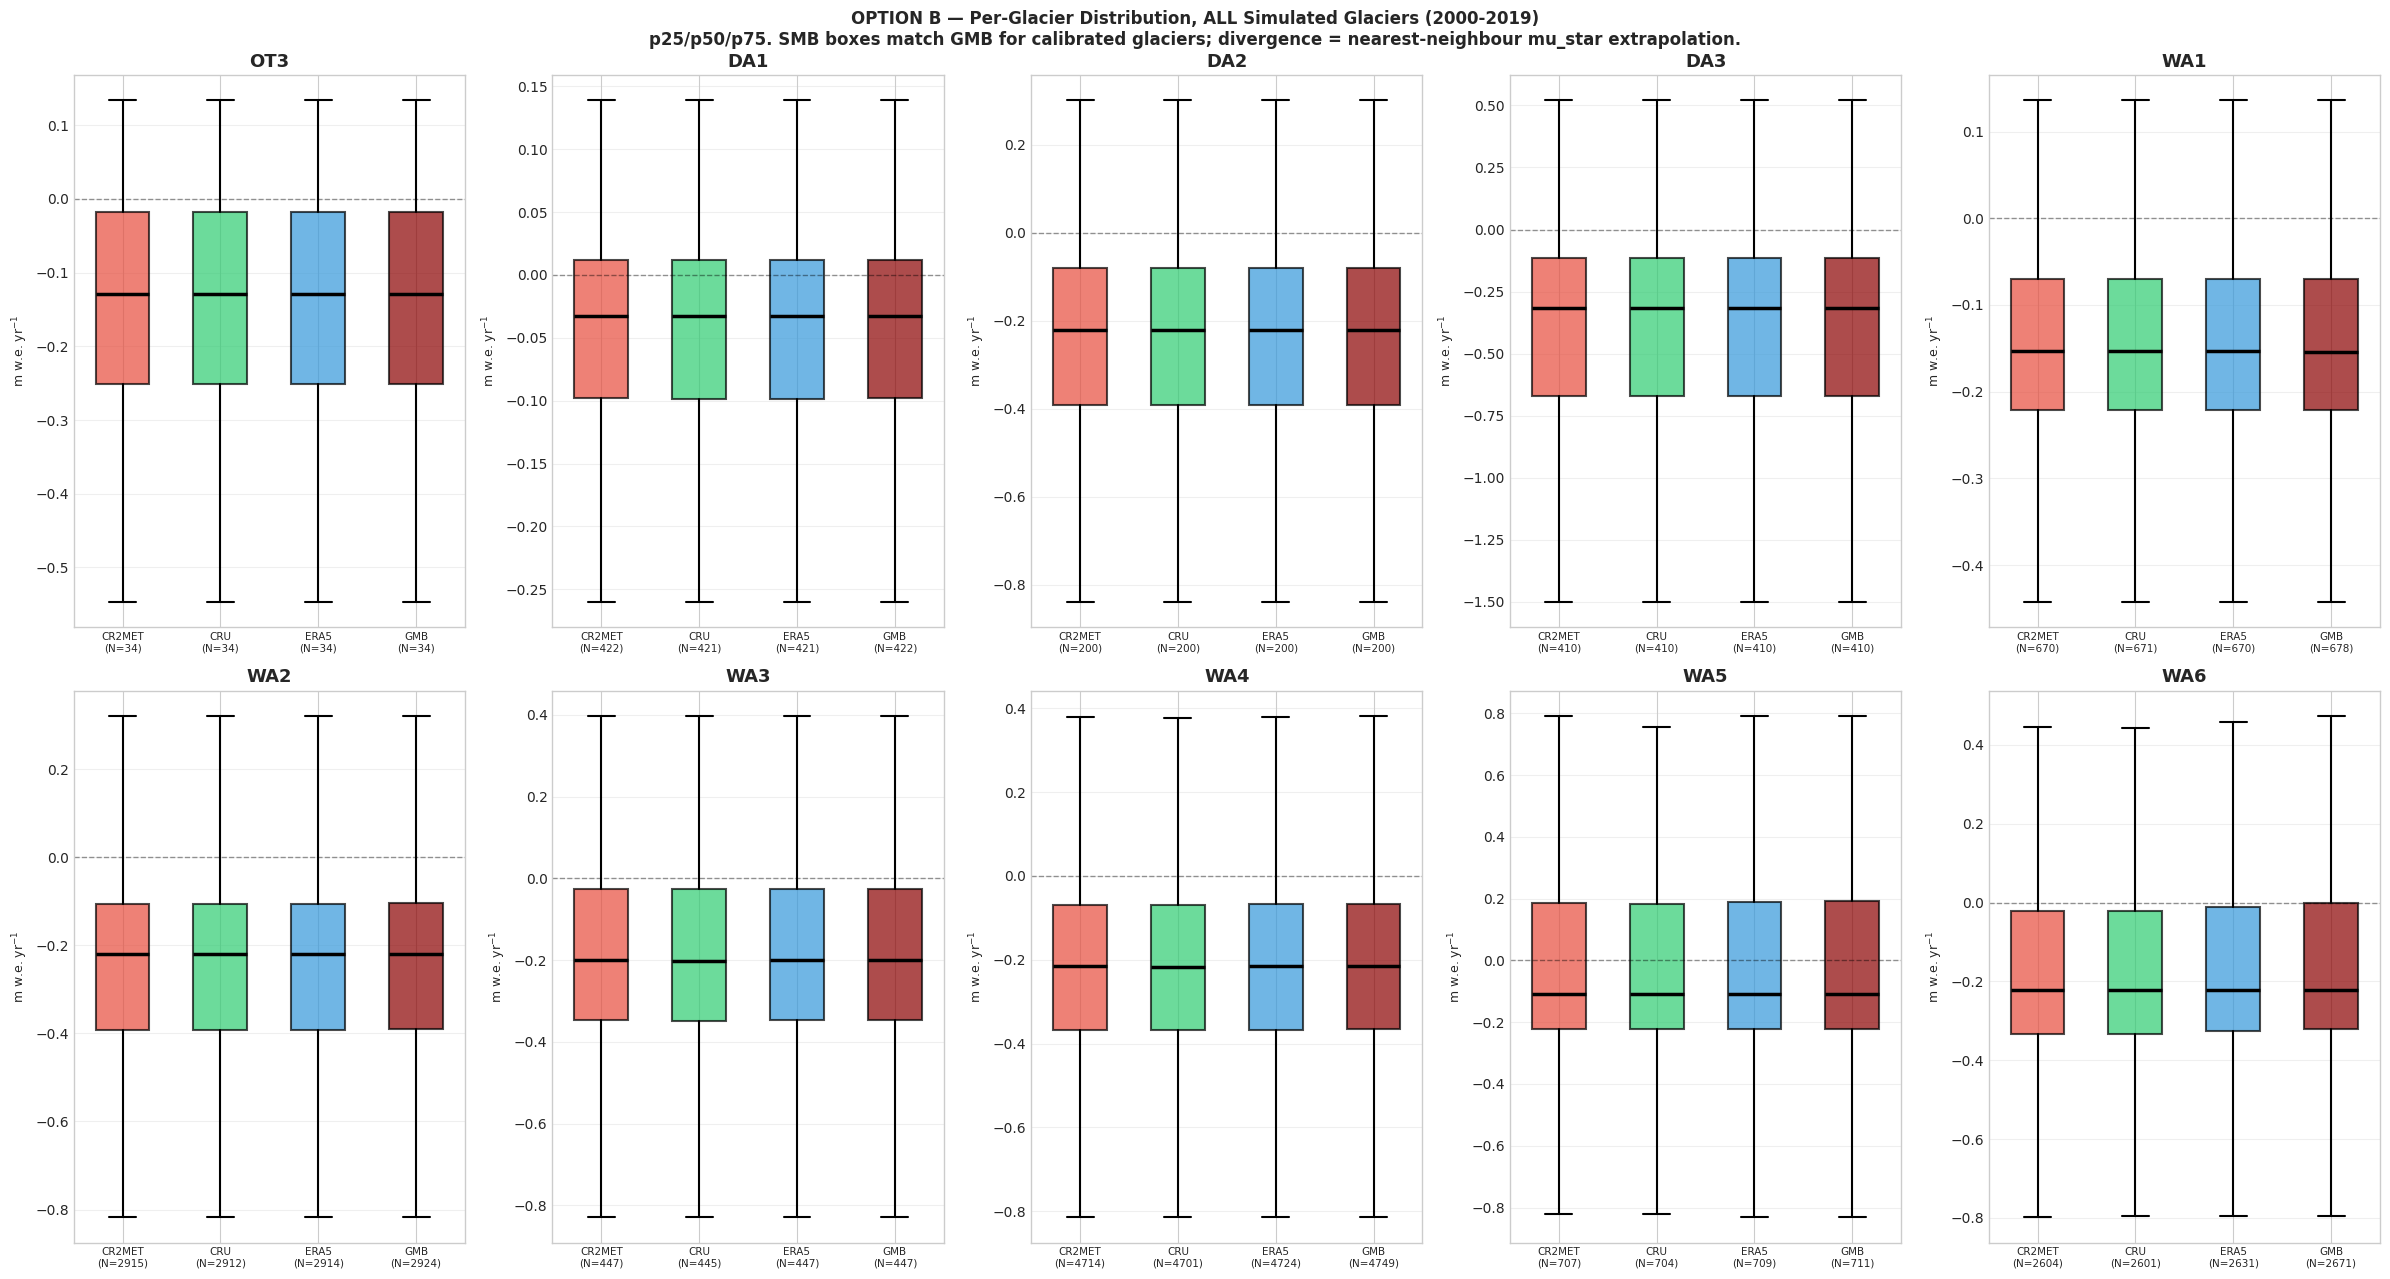

Generating Option C...


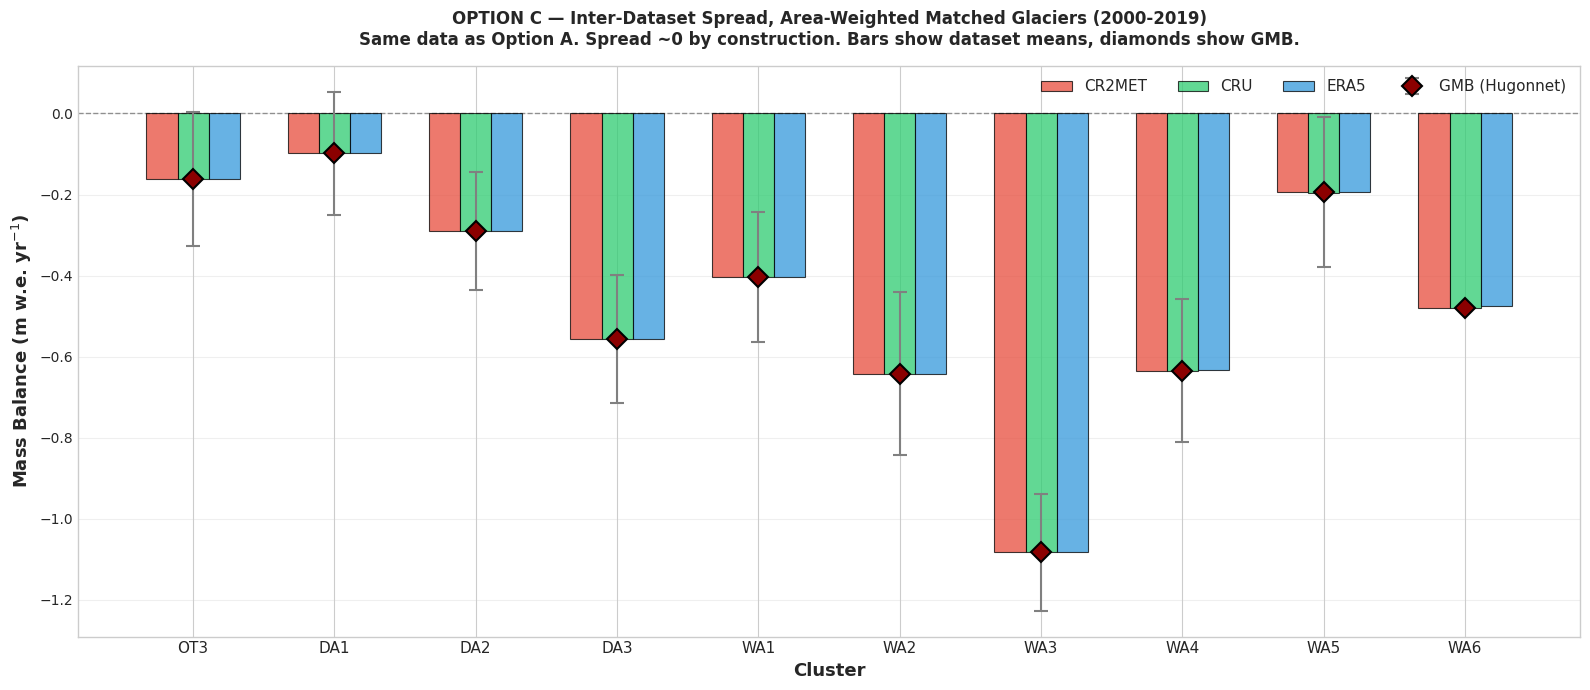


N glaciers per dataset per cluster:
Cluster     CR2MET       CRU      ERA5       GMB
------------------------------------------------
OT3             34        34        34        34
DA1            422       421       421       422
DA2            200       200       200       200
DA3            410       410       410       410
WA1            670       671       670       678
WA2           2915      2912      2914      2924
WA3            447       445       447       447
WA4           4714      4701      4724      4749
WA5            707       704       709       711
WA6           2604      2601      2631      2671

Notes for Alexis:
  Option A: clean for paper, but spread ~0 — only shows calibration works
  Option B: richer, shows all glaciers including nearest-neighbour extrapolation
  Option C: same as A visually, least informative of the three

N glaciers and total area (km²) per dataset per cluster:
Cluster     CR2MET   (km²)       CRU   (km²)      ERA5   (km²)       GMB   (km²)

In [5]:
# ── Cell 4/5: Three figure options for Alexis review ──────────────────────
#
# OPTION A: Cluster-level area-weighted SMB vs GMB (errorbar)
#   - Only matched glaciers (those with Hugonnet GMB)
#   - Confirms calibration — spread ~0 by construction
#   - Clean and simple
#
# OPTION B: Per-glacier box plots — ALL simulated glaciers
#   - 4 columns per cluster: CR2MET, CRU, ERA5, GMB
#   - p25/p50/p75, no fliers
#   - Shows nearest-neighbour extrapolation effect
#   - N glaciers per column shown
#
# OPTION C: Inter-dataset spread bar chart (area-weighted, matched glaciers)
#   - Same data as Option A, different visual
#   - Spread ~0 everywhere — probably least useful

# ── Shared data: per-glacier SMB for ALL glaciers ─────────────────────────
all_glacier_smb = {}  # {dataset: {cluster: Series}}
for dataset in datasets:
    all_glacier_smb[dataset] = {}
    for cluster in clusters:
        mb_file = f'{base_path}{dataset}/{cluster}/mb.csv'
        if not os.path.exists(mb_file):
            continue
        mb_df     = pd.read_csv(mb_file).set_index('rgi_id')
        year_cols = mb_df.columns[:20]
        smb_all   = mb_df[year_cols].mean(axis=1).dropna() / 1000
        all_glacier_smb[dataset][cluster] = smb_all

# ═══════════════════════════════════════════════════════════════════════════
# OPTION A: Cluster-level area-weighted errorbar
# ═══════════════════════════════════════════════════════════════════════════
print('Generating Option A...')
fig, ax = plt.subplots(figsize=(18, 8))
x_pos   = np.arange(len(clusters))
width   = 0.18
offsets = {'CR2MET': -1.5, 'CRU': -0.5, 'ERA5': 0.5}

for dataset in datasets:
    df_ds = df[df['dataset'] == dataset].sort_values(
        'cluster', key=lambda x: pd.Categorical(x, categories=clusters, ordered=True))
    ax.errorbar(x_pos + offsets[dataset] * width,
                df_ds['SMB'], yerr=df_ds['SMB_std'],
                fmt='o', markersize=9, color=colors[dataset],
                capsize=4, capthick=2, linewidth=1.5, alpha=0.85,
                label=dataset, markeredgecolor='black', markeredgewidth=1.2)

gmb_ref = df[df['dataset'] == 'CR2MET'].sort_values(
    'cluster', key=lambda x: pd.Categorical(x, categories=clusters, ordered=True))
ax.errorbar(x_pos + 1.5 * width, gmb_ref['GMB'], yerr=gmb_ref['GMB_error'],
            fmt='D', markersize=11, color='darkred',
            markeredgecolor='black', markeredgewidth=1.5,
            ecolor='gray', capsize=5, capthick=2, linewidth=1.5,
            label='GMB (Hugonnet)', zorder=10, alpha=0.9)

ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.4)
ax.set_ylabel('Mass Balance (m w.e. yr$^{-1}$)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=13, fontweight='bold')
ax.set_title('OPTION A — Area-Weighted Cluster SMB vs GMB (2000-2019)\n'
             'Only matched glaciers. Error bars = glacier std dev. '
             'Spread ~0 by construction (calibration).',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
x_labels = []
for cluster in clusters:
    ns = {ds: int(df[(df['cluster']==cluster)&(df['dataset']==ds)]['n_glaciers'].iloc[0])
          if len(df[(df['cluster']==cluster)&(df['dataset']==ds)]) > 0 else 0
          for ds in datasets}
    x_labels.append(f"{cluster}\nCR2={ns['CR2MET']}\nCRU={ns['CRU']}\nERA={ns['ERA5']}")
ax.set_xticklabels(x_labels, fontsize=8)
ax.legend(loc='lower left', fontsize=11, ncol=4)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# OPTION B: Per-glacier box plots — ALL glaciers
# ═══════════════════════════════════════════════════════════════════════════
print('Generating Option B...')
fig, axes = plt.subplots(2, 5, figsize=(24, 13), sharey=False)
axes_flat = axes.flatten()
n_summary = {ds: {} for ds in datasets + ['GMB']}

for ax_idx, cluster in enumerate(clusters):
    ax = axes_flat[ax_idx]
    box_data, tick_labels, box_colors, n_counts = [], [], [], []

    for dataset in datasets:
        if cluster in all_glacier_smb[dataset]:
            smb_all = all_glacier_smb[dataset][cluster]
            box_data.append(smb_all.values)
            n_counts.append(len(smb_all))
            n_summary[dataset][cluster] = len(smb_all)
        else:
            box_data.append([np.nan])
            n_counts.append(0)
        tick_labels.append(dataset)
        box_colors.append(colors[dataset])

    gmb_vals = geodetic_ref.loc[
        glacier_lists[cluster]['with_gmb'], 'dmdtda'].dropna().values
    box_data.append(gmb_vals)
    tick_labels.append('GMB')
    box_colors.append('darkred')
    n_counts.append(len(gmb_vals))
    n_summary['GMB'][cluster] = len(gmb_vals)

    bp = ax.boxplot(box_data, patch_artist=True, showfliers=False,
                    widths=0.55,
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    boxprops=dict(linewidth=1.5))

    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')

    ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.4)
    ax.set_title(cluster, fontsize=13, fontweight='bold')
    ax.set_ylabel('m w.e. yr$^{-1}$', fontsize=9)
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(
        [f'{lab}\n(N={n})' for lab, n in zip(tick_labels, n_counts)],
        fontsize=7.5)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    'OPTION B — Per-Glacier Distribution, ALL Simulated Glaciers (2000-2019)\n'
    'p25/p50/p75. SMB boxes match GMB for calibrated glaciers; '
    'divergence = nearest-neighbour mu_star extrapolation.',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# OPTION C: Inter-dataset spread bar chart (area-weighted, matched glaciers)
# ═══════════════════════════════════════════════════════════════════════════
print('Generating Option C...')
fig, ax = plt.subplots(figsize=(16, 7))
offsets_bar = {'CR2MET': -1, 'CRU': 0, 'ERA5': 1}
bar_width   = 0.22

for dataset in datasets:
    df_ds = df[df['dataset'] == dataset].sort_values(
        'cluster', key=lambda x: pd.Categorical(x, categories=clusters, ordered=True))
    ax.bar(x_pos + offsets_bar[dataset] * bar_width, df_ds['SMB'],
           width=bar_width, color=colors[dataset], alpha=0.75,
           edgecolor='black', linewidth=0.8, label=dataset)

ax.errorbar(x_pos, gmb_ref['GMB'], yerr=gmb_ref['GMB_error'],
            fmt='D', markersize=10, color='darkred',
            markeredgecolor='black', markeredgewidth=1.5,
            ecolor='gray', capsize=5, capthick=2,
            linewidth=1.5, label='GMB (Hugonnet)', zorder=10)

ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.4)
ax.set_ylabel('Mass Balance (m w.e. yr$^{-1}$)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=13, fontweight='bold')
ax.set_title('OPTION C — Inter-Dataset Spread, Area-Weighted Matched Glaciers (2000-2019)\n'
             'Same data as Option A. Spread ~0 by construction. '
             'Bars show dataset means, diamonds show GMB.',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(clusters, fontsize=11)
ax.legend(fontsize=11, ncol=4)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── N glaciers summary ─────────────────────────────────────────────────────
print('\nN glaciers per dataset per cluster:')
header = f'{"Cluster":<8}' + ''.join(f'{ds:>10}' for ds in datasets + ['GMB'])
print(header)
print('-' * len(header))
for cluster in clusters:
    row = f'{cluster:<8}'
    for ds in datasets + ['GMB']:
        row += f'{n_summary[ds].get(cluster, 0):>10}'
    print(row)

print('\nNotes for Alexis:')
print('  Option A: clean for paper, but spread ~0 — only shows calibration works')
print('  Option B: richer, shows all glaciers including nearest-neighbour extrapolation')
print('  Option C: same as A visually, least informative of the three')

# ── N glaciers + total area summary ───────────────────────────────────────
print('\nN glaciers and total area (km²) per dataset per cluster:')
header = f'{"Cluster":<8}' + ''.join(f'{ds:>10}{"(km²)":>8}' for ds in datasets + ['GMB'])
print(header)
print('-' * (8 + 18 * (len(datasets) + 1)))

for cluster in clusters:
    row = f'{cluster:<8}'
    
    # SMB datasets
    for dataset in datasets:
        mb_file = f'{base_path}{dataset}/{cluster}/mb.csv'
        if os.path.exists(mb_file):
            mb_df     = pd.read_csv(mb_file).set_index('rgi_id')
            year_cols = mb_df.columns[:20]
            ran       = mb_df[year_cols].dropna(how='all').index.tolist()
            matched   = [g for g in ran if g in geodetic_ref.index]
            n         = len(matched)
            area      = geodetic_ref.loc[matched, 'area'].sum() / 1e6  # m² → km²
        else:
            n, area = 0, 0.0
        row += f'{n:>10}{area:>7.1f} '
    
    # GMB
    gmb_glaciers = glacier_lists[cluster]['with_gmb']
    n_gmb        = len(gmb_glaciers)
    area_gmb     = geodetic_ref.loc[gmb_glaciers, 'area'].sum() / 1e6
    row += f'{n_gmb:>10}{area_gmb:>7.1f} '
    print(row)

# Chile-wide totals
print('-' * (8 + 18 * (len(datasets) + 1)))
row = f'{"TOTAL":<8}'
for dataset in datasets:
    total_n, total_area = 0, 0.0
    for cluster in clusters:
        mb_file = f'{base_path}{dataset}/{cluster}/mb.csv'
        if os.path.exists(mb_file):
            mb_df     = pd.read_csv(mb_file).set_index('rgi_id')
            year_cols = mb_df.columns[:20]
            ran       = mb_df[year_cols].dropna(how='all').index.tolist()
            matched   = [g for g in ran if g in geodetic_ref.index]
            total_n   += len(matched)
            total_area += geodetic_ref.loc[matched, 'area'].sum() / 1e6
    row += f'{total_n:>10}{total_area:>7.1f} '

# GMB total
all_gmb   = [g for c in clusters for g in glacier_lists[c]['with_gmb']]
n_gmb_tot = len(all_gmb)
area_gmb_tot = geodetic_ref.loc[all_gmb, 'area'].sum() / 1e6
row += f'{n_gmb_tot:>10}{area_gmb_tot:>7.1f} '
print(row)

print('\nNote: area in km² from Hugonnet geodetic_ref.')
print('      Large glaciers (Pio XI, San Rafael) dominate area in WA clusters')
print('      — N alone is misleading for area-weighted comparisons in Patagonia.')

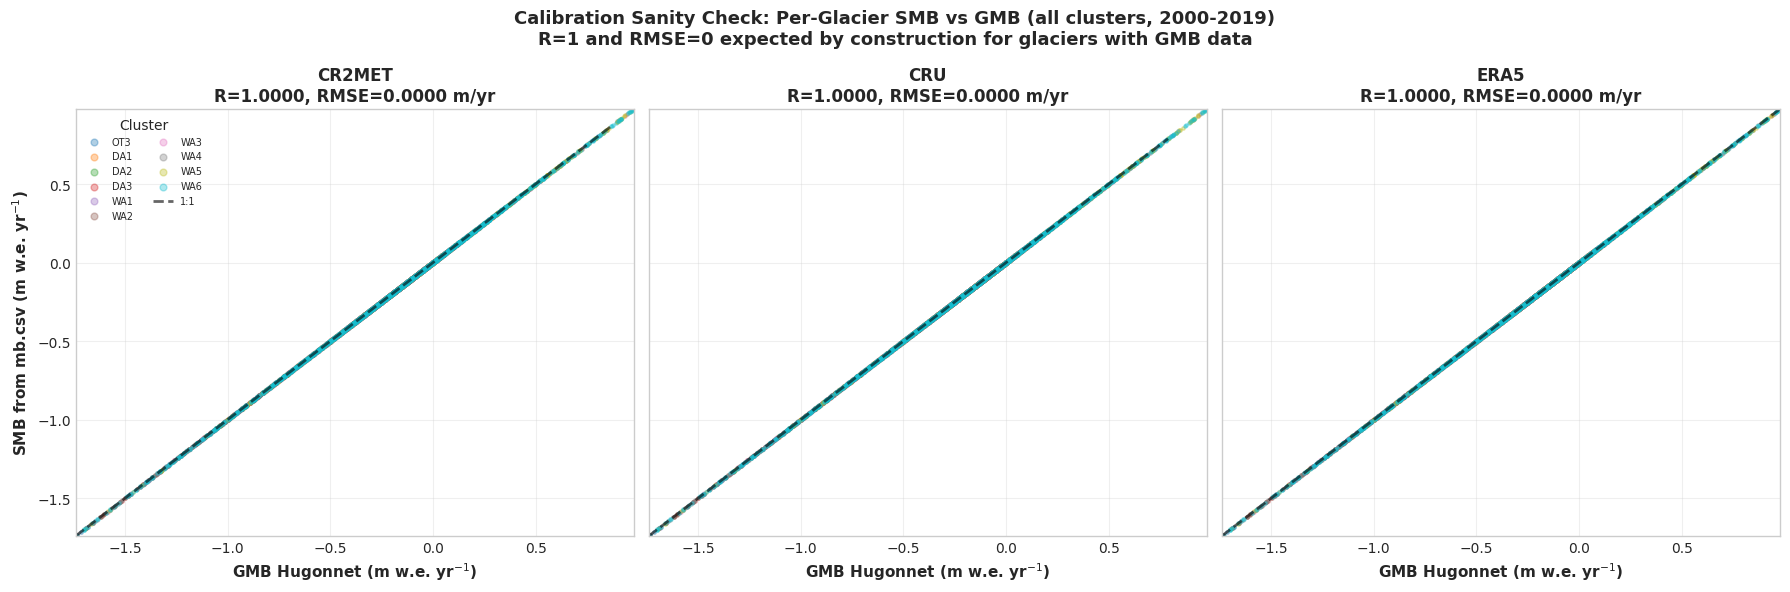

In [6]:
# ── Cell 5: Per-glacier SMB vs GMB — calibration sanity check ────────────
# One point per glacier, SMB (mb.csv mean 2000-2019) vs Hugonnet GMB.
# By construction these should fall on the 1:1 line (R=1, RMSE=0) for
# glaciers that have GMB data — this confirms calibration worked correctly.
# Any scatter would indicate a problem. This is a diagnostic figure only.

cluster_colors = plt.cm.tab10(np.linspace(0, 1, len(clusters)))
cluster_color_map = dict(zip(clusters, cluster_colors))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)

for ax, dataset in zip(axes, datasets):
    all_smb, all_gmb = [], []

    for cluster in clusters:
        mb_file = f'{base_path}{dataset}/{cluster}/mb.csv'
        if not os.path.exists(mb_file):
            continue
        mb_df   = pd.read_csv(mb_file).set_index('rgi_id')
        matched = [g for g in glacier_lists[cluster]['with_gmb'] if g in mb_df.index]
        if not matched:
            continue

        year_cols = mb_df.columns[:20]
        valid     = mb_df.loc[matched, year_cols].notna().all(axis=1)
        matched   = [g for g in matched if valid[g]]

        smb_vals = mb_df.loc[matched, year_cols].mean(axis=1).values / 1000  # m/yr
        gmb_vals = geodetic_ref.loc[matched, 'dmdtda'].values                # m/yr

        ax.scatter(gmb_vals, smb_vals, s=6, alpha=0.35,
                   color=cluster_color_map[cluster], label=cluster)
        all_smb.extend(smb_vals)
        all_gmb.extend(gmb_vals)

    all_smb = np.array(all_smb)
    all_gmb = np.array(all_gmb)
    mask    = np.isfinite(all_smb) & np.isfinite(all_gmb)

    # Use percentile range to avoid outlier-driven axis corruption
    p1  = np.nanpercentile(np.concatenate([all_gmb[mask], all_smb[mask]]), 1)
    p99 = np.nanpercentile(np.concatenate([all_gmb[mask], all_smb[mask]]), 99)
    ax.plot([p1, p99], [p1, p99], 'k--', linewidth=2, alpha=0.6, label='1:1')

    r    = np.corrcoef(all_smb[mask], all_gmb[mask])[0, 1]
    rmse = np.sqrt(np.mean((all_smb[mask] - all_gmb[mask])**2))
    ax.set_title(f'{dataset}\nR={r:.4f}, RMSE={rmse:.4f} m/yr',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('GMB Hugonnet (m w.e. yr$^{-1}$)', fontsize=11, fontweight='bold')
    ax.set_xlim(p1, p99)
    ax.set_ylim(p1, p99)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('SMB from mb.csv (m w.e. yr$^{-1}$)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=7, ncol=2, markerscale=2, title='Cluster')

plt.suptitle(
    'Calibration Sanity Check: Per-Glacier SMB vs GMB (all clusters, 2000-2019)\n'
    'R=1 and RMSE=0 expected by construction for glaciers with GMB data',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

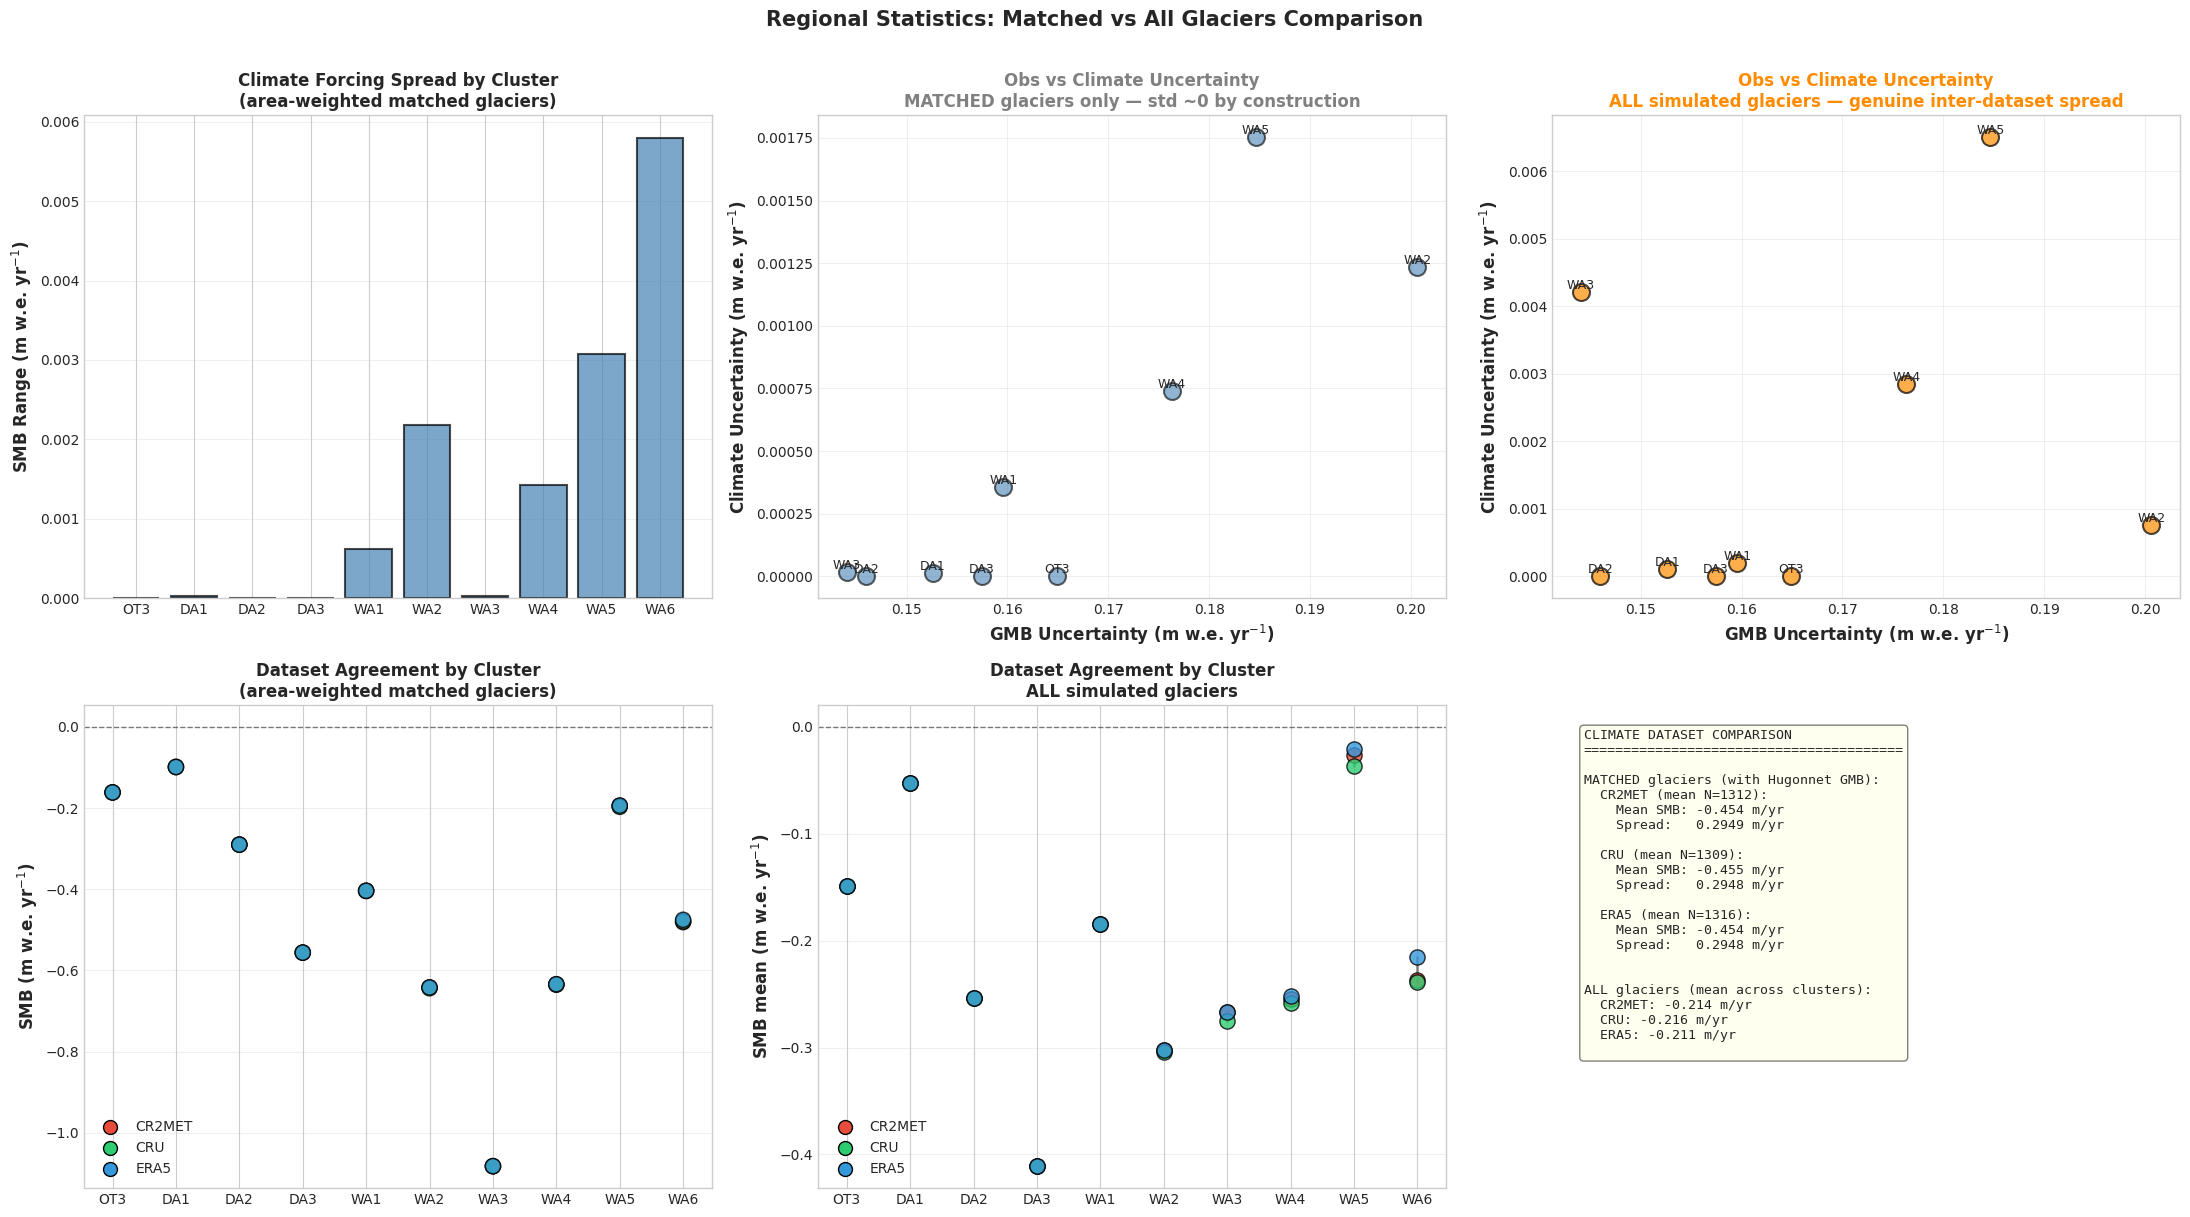

In [7]:
# ── Cell 6: Regional statistics panels ────────────────────────────────────
# axes[0,1] shown in two versions:
#   - Version MATCHED: climate uncertainty from matched glaciers only (std ~0)
#   - Version ALL: climate uncertainty from all simulated glaciers
# Per Alexis: matched version is circular (SMB=GMB by construction).
# ALL version is more meaningful — shows genuine inter-dataset disagreement.

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

cluster_stats = []
for cluster in clusters:
    cluster_df = df[df['cluster'] == cluster]

    # Climate uncertainty from matched glaciers (std ~0 by construction)
    clim_unc_matched = cluster_df['SMB'].std()

    # Climate uncertainty from ALL simulated glaciers
    all_stds = []
    for dataset in datasets:
        if cluster in all_glacier_smb.get(dataset, {}):
            all_stds.append(all_glacier_smb[dataset][cluster].mean())
    clim_unc_all = np.std(all_stds) if len(all_stds) == 3 else np.nan

    cluster_stats.append({
        'cluster':               cluster,
        'SMB_range':             cluster_df['SMB'].max() - cluster_df['SMB'].min(),
        'SMB_mean':              cluster_df['SMB'].mean(),
        'climate_unc_matched':   clim_unc_matched,
        'climate_unc_all':       clim_unc_all,
        'GMB':                   cluster_df['GMB'].iloc[0]
    })
stats_df = pd.DataFrame(cluster_stats)

# ── Panel 1: SMB range by cluster ─────────────────────────────────────────
ax = axes[0, 0]
ax.bar(np.arange(len(clusters)), stats_df['SMB_range'],
       color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('SMB Range (m w.e. yr$^{-1}$)', fontsize=12, fontweight='bold')
ax.set_title('Climate Forcing Spread by Cluster\n(area-weighted matched glaciers)',
             fontsize=12, fontweight='bold')
ax.set_xticks(np.arange(len(clusters)))
ax.set_xticklabels(clusters, fontsize=10)
ax.grid(axis='y', alpha=0.3)

# ── Panel 2a: Obs vs Climate uncertainty — MATCHED glaciers ───────────────
ax = axes[0, 1]
gmb_unc      = df[df['dataset'] == 'CR2MET'].set_index('cluster')['GMB_error']
clim_matched = stats_df.set_index('cluster')['climate_unc_matched']
ax.scatter(gmb_unc, clim_matched, s=150, alpha=0.6,
           edgecolors='black', linewidth=1.5, color='steelblue')
for cluster in clusters:
    ax.annotate(cluster, (gmb_unc[cluster], clim_matched[cluster]),
                fontsize=9, ha='center', va='bottom')
ax.set_xlabel('GMB Uncertainty (m w.e. yr$^{-1}$)', fontsize=12, fontweight='bold')
ax.set_ylabel('Climate Uncertainty (m w.e. yr$^{-1}$)', fontsize=12, fontweight='bold')
ax.set_title('Obs vs Climate Uncertainty\nMATCHED glaciers only — std ~0 by construction',
             fontsize=12, fontweight='bold', color='gray')
ax.grid(alpha=0.3)

# ── Panel 2b: Obs vs Climate uncertainty — ALL glaciers ───────────────────
ax = axes[0, 2]
clim_all = stats_df.set_index('cluster')['climate_unc_all']
ax.scatter(gmb_unc, clim_all, s=150, alpha=0.7,
           edgecolors='black', linewidth=1.5, color='darkorange')
for cluster in clusters:
    if not np.isnan(clim_all[cluster]):
        ax.annotate(cluster, (gmb_unc[cluster], clim_all[cluster]),
                    fontsize=9, ha='center', va='bottom')
ax.set_xlabel('GMB Uncertainty (m w.e. yr$^{-1}$)', fontsize=12, fontweight='bold')
ax.set_ylabel('Climate Uncertainty (m w.e. yr$^{-1}$)', fontsize=12, fontweight='bold')
ax.set_title('Obs vs Climate Uncertainty\nALL simulated glaciers — genuine inter-dataset spread',
             fontsize=12, fontweight='bold', color='darkorange')
ax.grid(alpha=0.3)

# ── Panel 3: Dataset agreement per cluster ────────────────────────────────
ax = axes[1, 0]
for i, cluster in enumerate(clusters):
    cluster_df = df[df['cluster'] == cluster]
    smb_vals   = cluster_df['SMB'].values
    ax.scatter([i]*len(smb_vals), smb_vals, s=120,
               color=[colors[ds] for ds in cluster_df['dataset']],
               alpha=0.8, edgecolors='black', linewidth=1, zorder=5)
    ax.plot([i, i], [smb_vals.min(), smb_vals.max()],
            'k-', linewidth=2, alpha=0.4)
ax.set_ylabel('SMB (m w.e. yr$^{-1}$)', fontsize=12, fontweight='bold')
ax.set_title('Dataset Agreement by Cluster\n(area-weighted matched glaciers)',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(len(clusters)))
ax.set_xticklabels(clusters, fontsize=10)
ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
# Add legend
for ds in datasets:
    ax.scatter([], [], color=colors[ds], s=100, label=ds,
               edgecolors='black', linewidth=1)
ax.legend(fontsize=10)

# ── Panel 4: Dataset agreement — ALL glaciers ─────────────────────────────
ax = axes[1, 1]
for i, cluster in enumerate(clusters):
    vals_per_ds = []
    for dataset in datasets:
        if cluster in all_glacier_smb.get(dataset, {}):
            vals_per_ds.append((dataset, all_glacier_smb[dataset][cluster].mean()))
    for dataset, val in vals_per_ds:
        ax.scatter(i, val, s=120, color=colors[dataset],
                   alpha=0.8, edgecolors='black', linewidth=1, zorder=5)
    if vals_per_ds:
        yvals = [v for _, v in vals_per_ds]
        ax.plot([i, i], [min(yvals), max(yvals)],
                'k-', linewidth=2, alpha=0.4)
ax.set_ylabel('SMB mean (m w.e. yr$^{-1}$)', fontsize=12, fontweight='bold')
ax.set_title('Dataset Agreement by Cluster\nALL simulated glaciers',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(len(clusters)))
ax.set_xticklabels(clusters, fontsize=10)
ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
for ds in datasets:
    ax.scatter([], [], color=colors[ds], s=100, label=ds,
               edgecolors='black', linewidth=1)
ax.legend(fontsize=10)

# ── Panel 5: Summary statistics ───────────────────────────────────────────
ax = axes[1, 2]
ax.axis('off')
summary_text = 'CLIMATE DATASET COMPARISON\n' + '='*40 + '\n\n'
summary_text += 'MATCHED glaciers (with Hugonnet GMB):\n'
for dataset in datasets:
    df_ds  = df[df['dataset'] == dataset]
    n_mean = int(df_ds['n_glaciers'].mean())
    summary_text += f'  {dataset} (mean N={n_mean}):\n'
    summary_text += f'    Mean SMB: {df_ds["SMB"].mean():.3f} m/yr\n'
    summary_text += f'    Spread:   {df_ds["SMB"].std():.4f} m/yr\n\n'
summary_text += '\nALL glaciers (mean across clusters):\n'
for dataset in datasets:
    all_means = [all_glacier_smb[dataset][c].mean()
                 for c in clusters if c in all_glacier_smb.get(dataset, {})]
    if all_means:
        summary_text += f'  {dataset}: {np.mean(all_means):.3f} m/yr\n'
ax.text(0.05, 0.95, summary_text, fontsize=9.5, family='monospace',
        verticalalignment='top', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.suptitle('Regional Statistics: Matched vs All Glaciers Comparison',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_3607/272678507.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True,


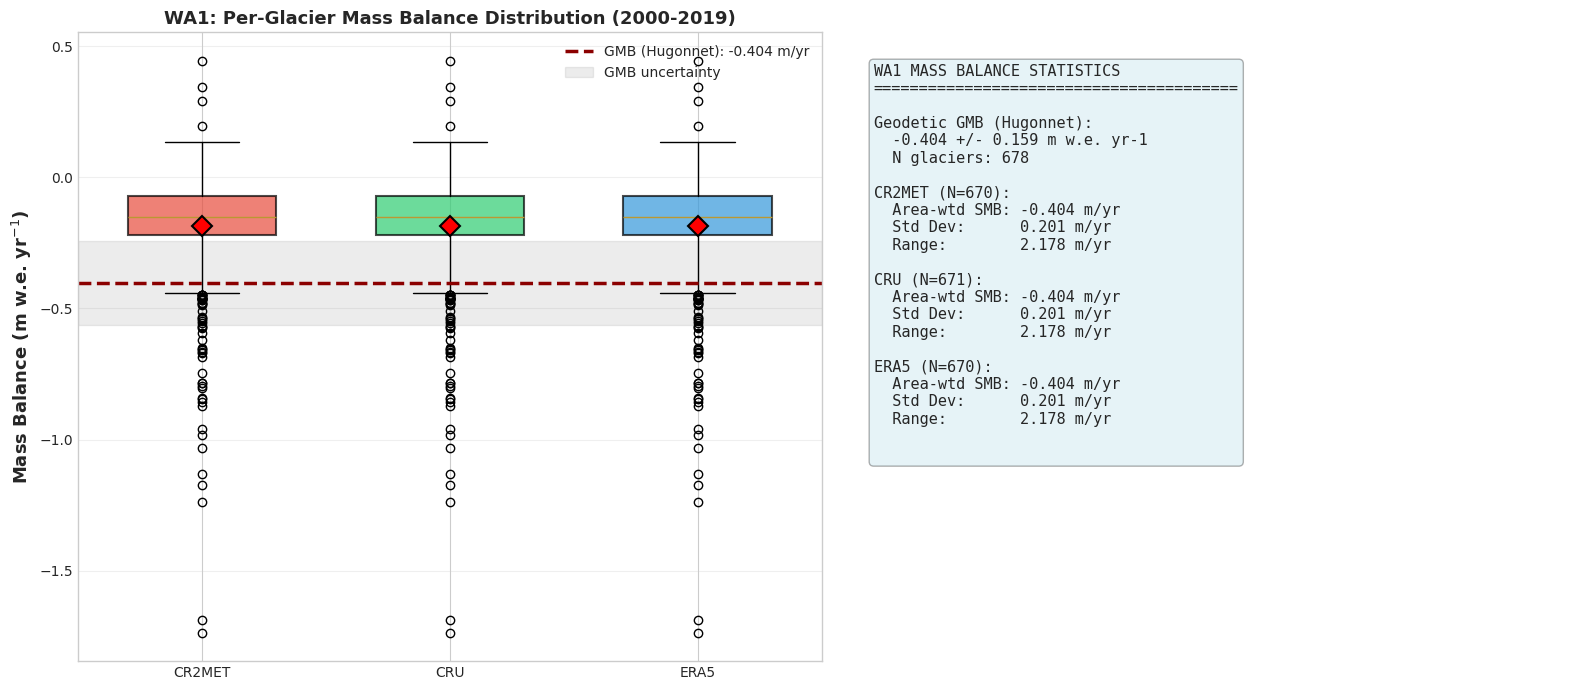

✓ WA1 mass balance statistics displayed


In [8]:
# ── Cell 7: WA1 per-glacier mass balance distribution (box plot) ───────────
# GMB reference computed directly from Hugonnet for all WA1 glaciers.

wa1_glacier_data = {}
for dataset in datasets:
    mb_file = f'{base_path}{dataset}/WA1/mb.csv'
    if os.path.exists(mb_file):
        mb_df = pd.read_csv(mb_file).set_index('rgi_id')
        year_cols = mb_df.columns[:20]
        glacier_means = mb_df[year_cols].mean(axis=1) / 1000  # mm -> m
        wa1_glacier_data[dataset] = glacier_means.dropna()

# WA1 GMB from Hugonnet directly
wa1_matched = glacier_lists['WA1']['with_gmb']
wa1_weights = geodetic_ref.loc[wa1_matched, 'area']
wa1_gmb     = np.average(geodetic_ref.loc[wa1_matched, 'dmdtda'] * 1000,     weights=wa1_weights) / 1000
wa1_gmb_err = np.average(geodetic_ref.loc[wa1_matched, 'err_dmdtda'] * 1000, weights=wa1_weights) / 1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

box_data   = [wa1_glacier_data[ds].values for ds in datasets if ds in wa1_glacier_data]
box_labels = [ds for ds in datasets if ds in wa1_glacier_data]
bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True,
                 showmeans=True, widths=0.6,
                 meanprops=dict(marker='D', markerfacecolor='red',
                                markersize=10, markeredgecolor='black',
                                markeredgewidth=1.5))
for patch, ds in zip(bp['boxes'], box_labels):
    patch.set_facecolor(colors[ds])
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

ax1.axhline(y=wa1_gmb, color='darkred', linestyle='--', linewidth=2.5,
            label=f'GMB (Hugonnet): {wa1_gmb:.3f} m/yr')
ax1.axhspan(wa1_gmb - wa1_gmb_err, wa1_gmb + wa1_gmb_err,
            alpha=0.15, color='gray', label='GMB uncertainty')
ax1.set_ylabel('Mass Balance (m w.e. yr$^{-1}$)', fontsize=13, fontweight='bold')
ax1.set_title('WA1: Per-Glacier Mass Balance Distribution (2000-2019)',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

ax2.axis('off')
wa1_text  = 'WA1 MASS BALANCE STATISTICS\n' + '='*40 + '\n\n'
wa1_text += f'Geodetic GMB (Hugonnet):\n  {wa1_gmb:.3f} +/- {wa1_gmb_err:.3f} m w.e. yr-1\n'
wa1_text += f'  N glaciers: {len(wa1_matched)}\n\n'
for ds in datasets:
    if ds not in wa1_glacier_data:
        continue
    row    = df[(df['cluster'] == 'WA1') & (df['dataset'] == ds)]
    wa1_smb = row['SMB'].iloc[0]
    n       = int(row['n_glaciers'].iloc[0])
    data    = wa1_glacier_data[ds]
    wa1_text += f'{ds} (N={n}):\n'
    wa1_text += f'  Area-wtd SMB: {wa1_smb:.3f} m/yr\n'
    wa1_text += f'  Std Dev:      {data.std():.3f} m/yr\n'
    wa1_text += f'  Range:        {data.max()-data.min():.3f} m/yr\n\n'

ax2.text(0.05, 0.95, wa1_text, fontsize=11, family='monospace',
         verticalalignment='top', transform=ax2.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
plt.tight_layout()
plt.show()
print('✓ WA1 mass balance statistics displayed')

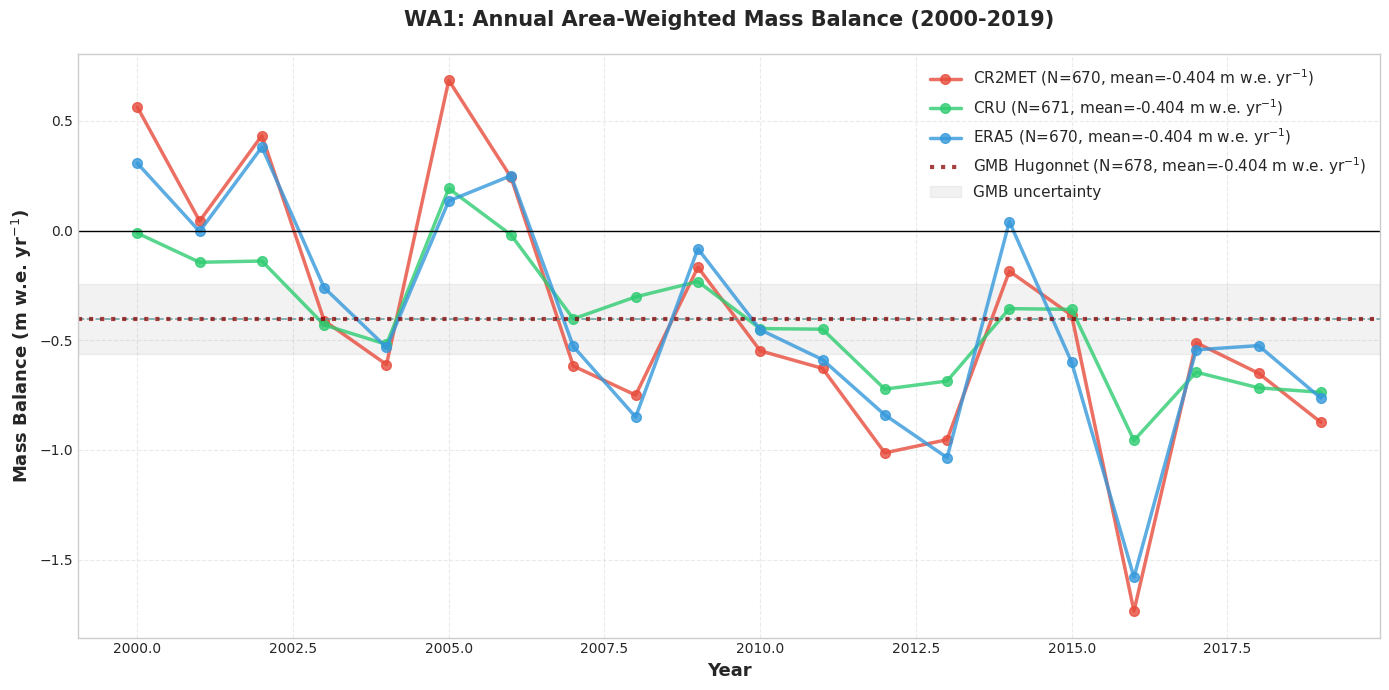

Year-to-year variability (std):
  CR2MET (N=670): 0.587 m/yr
  CRU (N=671): 0.291 m/yr
  ERA5 (N=670): 0.501 m/yr


In [9]:
# ── Cell 8: WA1 annual mass balance timeseries (from mb.csv) ──────────────
# Legend updated per Alexis: shows N glaciers and mean SMB per dataset.

wa1_annual = {}
wa1_n      = {}
for dataset in datasets:
    mb_file = f'{base_path}{dataset}/WA1/mb.csv'
    if not os.path.exists(mb_file):
        continue
    mb_df     = pd.read_csv(mb_file).set_index('rgi_id')
    year_cols = mb_df.columns[:20]
    matched   = [g for g in glacier_lists['WA1']['with_gmb'] if g in mb_df.index]
    weights   = geodetic_ref.loc[matched, 'area'].values
    annual_mb = [np.average(mb_df.loc[matched, col].values, weights=weights)
                 for col in year_cols]
    wa1_annual[dataset] = pd.DataFrame({
        'year': range(2000, 2020),
        'mb':   np.array(annual_mb) / 1000
    })
    wa1_n[dataset] = len(matched)

fig, ax = plt.subplots(figsize=(14, 7))

for dataset in datasets:
    if dataset not in wa1_annual:
        continue
    df_ts   = wa1_annual[dataset]
    mean_mb = df_ts['mb'].mean()
    n       = wa1_n[dataset]
    ax.plot(df_ts['year'], df_ts['mb'], 'o-',
            color=colors[dataset], linewidth=2.5, markersize=7,
            label=f'{dataset} (N={n}, mean={mean_mb:.3f} m w.e. yr$^{{-1}}$)',
            alpha=0.8)
    ax.axhline(y=mean_mb, color=colors[dataset], linestyle='--',
               linewidth=1.2, alpha=0.4)

ax.axhline(y=wa1_gmb, color='darkred', linestyle=':', linewidth=3,
           label=f'GMB Hugonnet (N={len(glacier_lists["WA1"]["with_gmb"])}, '
                 f'mean={wa1_gmb:.3f} m w.e. yr$^{{-1}}$)',
           alpha=0.75)
ax.axhspan(wa1_gmb - wa1_gmb_err, wa1_gmb + wa1_gmb_err,
           alpha=0.1, color='gray', label='GMB uncertainty')
ax.axhline(y=0, color='black', linewidth=1)
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Mass Balance (m w.e. yr$^{-1}$)', fontsize=13, fontweight='bold')
ax.set_title('WA1: Annual Area-Weighted Mass Balance (2000-2019)',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

print('Year-to-year variability (std):')
for dataset in datasets:
    if dataset in wa1_annual:
        n = wa1_n[dataset]
        print(f'  {dataset} (N={n}): {wa1_annual[dataset]["mb"].std():.3f} m/yr')

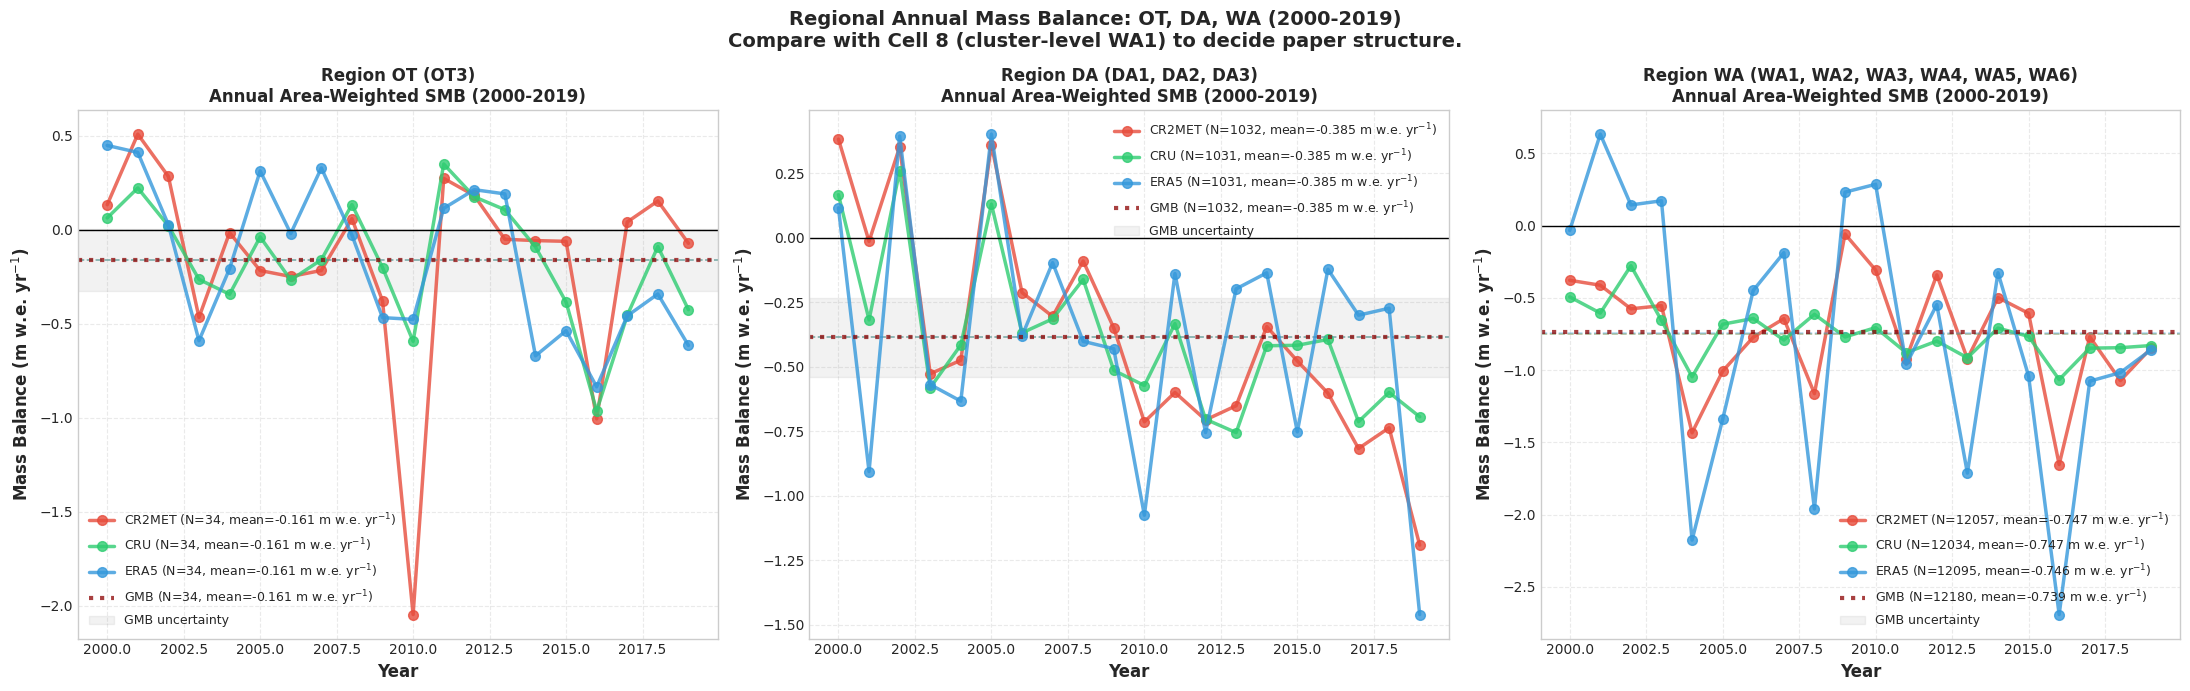

Regional mean SMB (2000-2019):
Region  Dataset          N    Mean SMB       Std
--------------------------------------------------
OT      CR2MET          34      -0.161     0.548
OT      CRU             34      -0.161     0.315
OT      ERA5            34      -0.161     0.406
OT      GMB             34      -0.161     0.165

DA      CR2MET        1032      -0.385     0.418
DA      CRU           1031      -0.385     0.293
DA      ERA5          1031      -0.385     0.463
DA      GMB           1032      -0.385     0.153

WA      CR2MET       12057      -0.747     0.394
WA      CRU          12034      -0.747     0.180
WA      ERA5         12095      -0.746     0.906
WA      GMB          12180      -0.739       nan



In [10]:
# ── Cell 8A: Regional aggregation — annual mass balance timeseries ─────────
# Aggregates clusters into 3 regions: OT, DA, WA.
# Each region's SMB is area-weighted across all glaciers in all its clusters.
# Per Alexis: evaluate whether paper shows results by cluster or by region.

regions = {
    'OT': ['OT3'],
    'DA': ['DA1', 'DA2', 'DA3'],
    'WA': ['WA1', 'WA2', 'WA3', 'WA4', 'WA5', 'WA6']
}
region_colors = {'OT': '#9b59b6', 'DA': '#e67e22', 'WA': '#1abc9c'}

# ── Compute regional annual SMB ────────────────────────────────────────────
regional_annual = {}   # {dataset: {region: DataFrame}}
regional_n      = {}   # {dataset: {region: int}}
regional_gmb    = {}   # {region: (gmb, gmb_err, n)}

for dataset in datasets:
    regional_annual[dataset] = {}
    regional_n[dataset]      = {}
    for region, region_clusters in regions.items():
        all_smb_weighted = np.zeros(20)
        total_weight     = 0
        n_total          = 0
        for cluster in region_clusters:
            mb_file = f'{base_path}{dataset}/{cluster}/mb.csv'
            if not os.path.exists(mb_file):
                continue
            mb_df     = pd.read_csv(mb_file).set_index('rgi_id')
            year_cols = mb_df.columns[:20]
            matched   = [g for g in glacier_lists[cluster]['with_gmb']
                         if g in mb_df.index]
            if not matched:
                continue
            weights = geodetic_ref.loc[matched, 'area'].values
            for i, col in enumerate(year_cols):
                all_smb_weighted[i] += np.sum(
                    mb_df.loc[matched, col].values * weights)
            total_weight += weights.sum()
            n_total      += len(matched)

        if total_weight > 0:
            regional_annual[dataset][region] = pd.DataFrame({
                'year': range(2000, 2020),
                'mb':   all_smb_weighted / total_weight / 1000  # m/yr
            })
            regional_n[dataset][region] = n_total

# ── Compute regional GMB ───────────────────────────────────────────────────
for region, region_clusters in regions.items():
    all_matched, all_weights = [], []
    for cluster in region_clusters:
        matched = glacier_lists[cluster]['with_gmb']
        all_matched.extend(matched)
        all_weights.extend(geodetic_ref.loc[matched, 'area'].values)
    all_weights = np.array(all_weights)
    gmb_vals    = geodetic_ref.loc[all_matched, 'dmdtda'].values
    gmb_err     = geodetic_ref.loc[all_matched, 'err_dmdtda'].values
    regional_gmb[region] = (
        np.average(gmb_vals, weights=all_weights),
        np.average(gmb_err,  weights=all_weights),
        len(all_matched)
    )

# ── Plot: one panel per region ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=False)

for ax, (region, region_clusters) in zip(axes, regions.items()):
    gmb_val, gmb_err_val, gmb_n = regional_gmb[region]

    for dataset in datasets:
        if region not in regional_annual.get(dataset, {}):
            continue
        df_ts   = regional_annual[dataset][region]
        mean_mb = df_ts['mb'].mean()
        n       = regional_n[dataset][region]
        ax.plot(df_ts['year'], df_ts['mb'], 'o-',
                color=colors[dataset], linewidth=2.5, markersize=7,
                label=f'{dataset} (N={n}, mean={mean_mb:.3f} m w.e. yr$^{{-1}}$)',
                alpha=0.8)
        ax.axhline(y=mean_mb, color=colors[dataset], linestyle='--',
                   linewidth=1.2, alpha=0.35)

    ax.axhline(y=gmb_val, color='darkred', linestyle=':', linewidth=3,
               label=f'GMB (N={gmb_n}, mean={gmb_val:.3f} m w.e. yr$^{{-1}}$)',
               alpha=0.75)
    ax.axhspan(gmb_val - gmb_err_val, gmb_val + gmb_err_val,
               alpha=0.1, color='gray', label='GMB uncertainty')
    ax.axhline(y=0, color='black', linewidth=1)

    cluster_str = ', '.join(region_clusters)
    ax.set_title(f'Region {region} ({cluster_str})\nAnnual Area-Weighted SMB (2000-2019)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mass Balance (m w.e. yr$^{-1}$)', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9, framealpha=0.95)
    ax.grid(True, alpha=0.4, linestyle='--')

plt.suptitle('Regional Annual Mass Balance: OT, DA, WA (2000-2019)\n'
             'Compare with Cell 8 (cluster-level WA1) to decide paper structure.',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────
print('Regional mean SMB (2000-2019):')
print(f'{"Region":<8}{"Dataset":<12}{"N":>6}{"Mean SMB":>12}{"Std":>10}')
print('-' * 50)
for region in regions:
    gmb_val, gmb_err_val, gmb_n = regional_gmb[region]
    for dataset in datasets:
        if region not in regional_annual.get(dataset, {}):
            continue
        df_ts   = regional_annual[dataset][region]
        n       = regional_n[dataset][region]
        print(f'{region:<8}{dataset:<12}{n:>6}'
              f'{df_ts["mb"].mean():>12.3f}'
              f'{df_ts["mb"].std():>10.3f}')
    print(f'{region:<8}{"GMB":<12}{gmb_n:>6}{gmb_val:>12.3f}'
          f'{gmb_err_val:>10.3f}')
    print()

## To Do: 
── Observational validation (per Alexis recommendation) ────────────
Compare annual SMB timeseries against monitored glaciers per region
to determine which climate product performs best:

OT: Echaurren Norte (RGI60-17.00564) — WGMS reference glacier
DA: Tapado (RGI60-16.xxxxx) — monitored by CEAZA
WA: Mocho-Choshuenco or Tyndall — wet Andes

Data sources:
WGMS: https://wgms.ch/data_databaseversions/
Ask Alexis if he has local observed SMB series

Method: extract per-glacier annual SMB from mb.csv for each monitored glacier, plot alongside observed series, compute RMSE per dataset. This will show which product tracks interannual variability best per region.

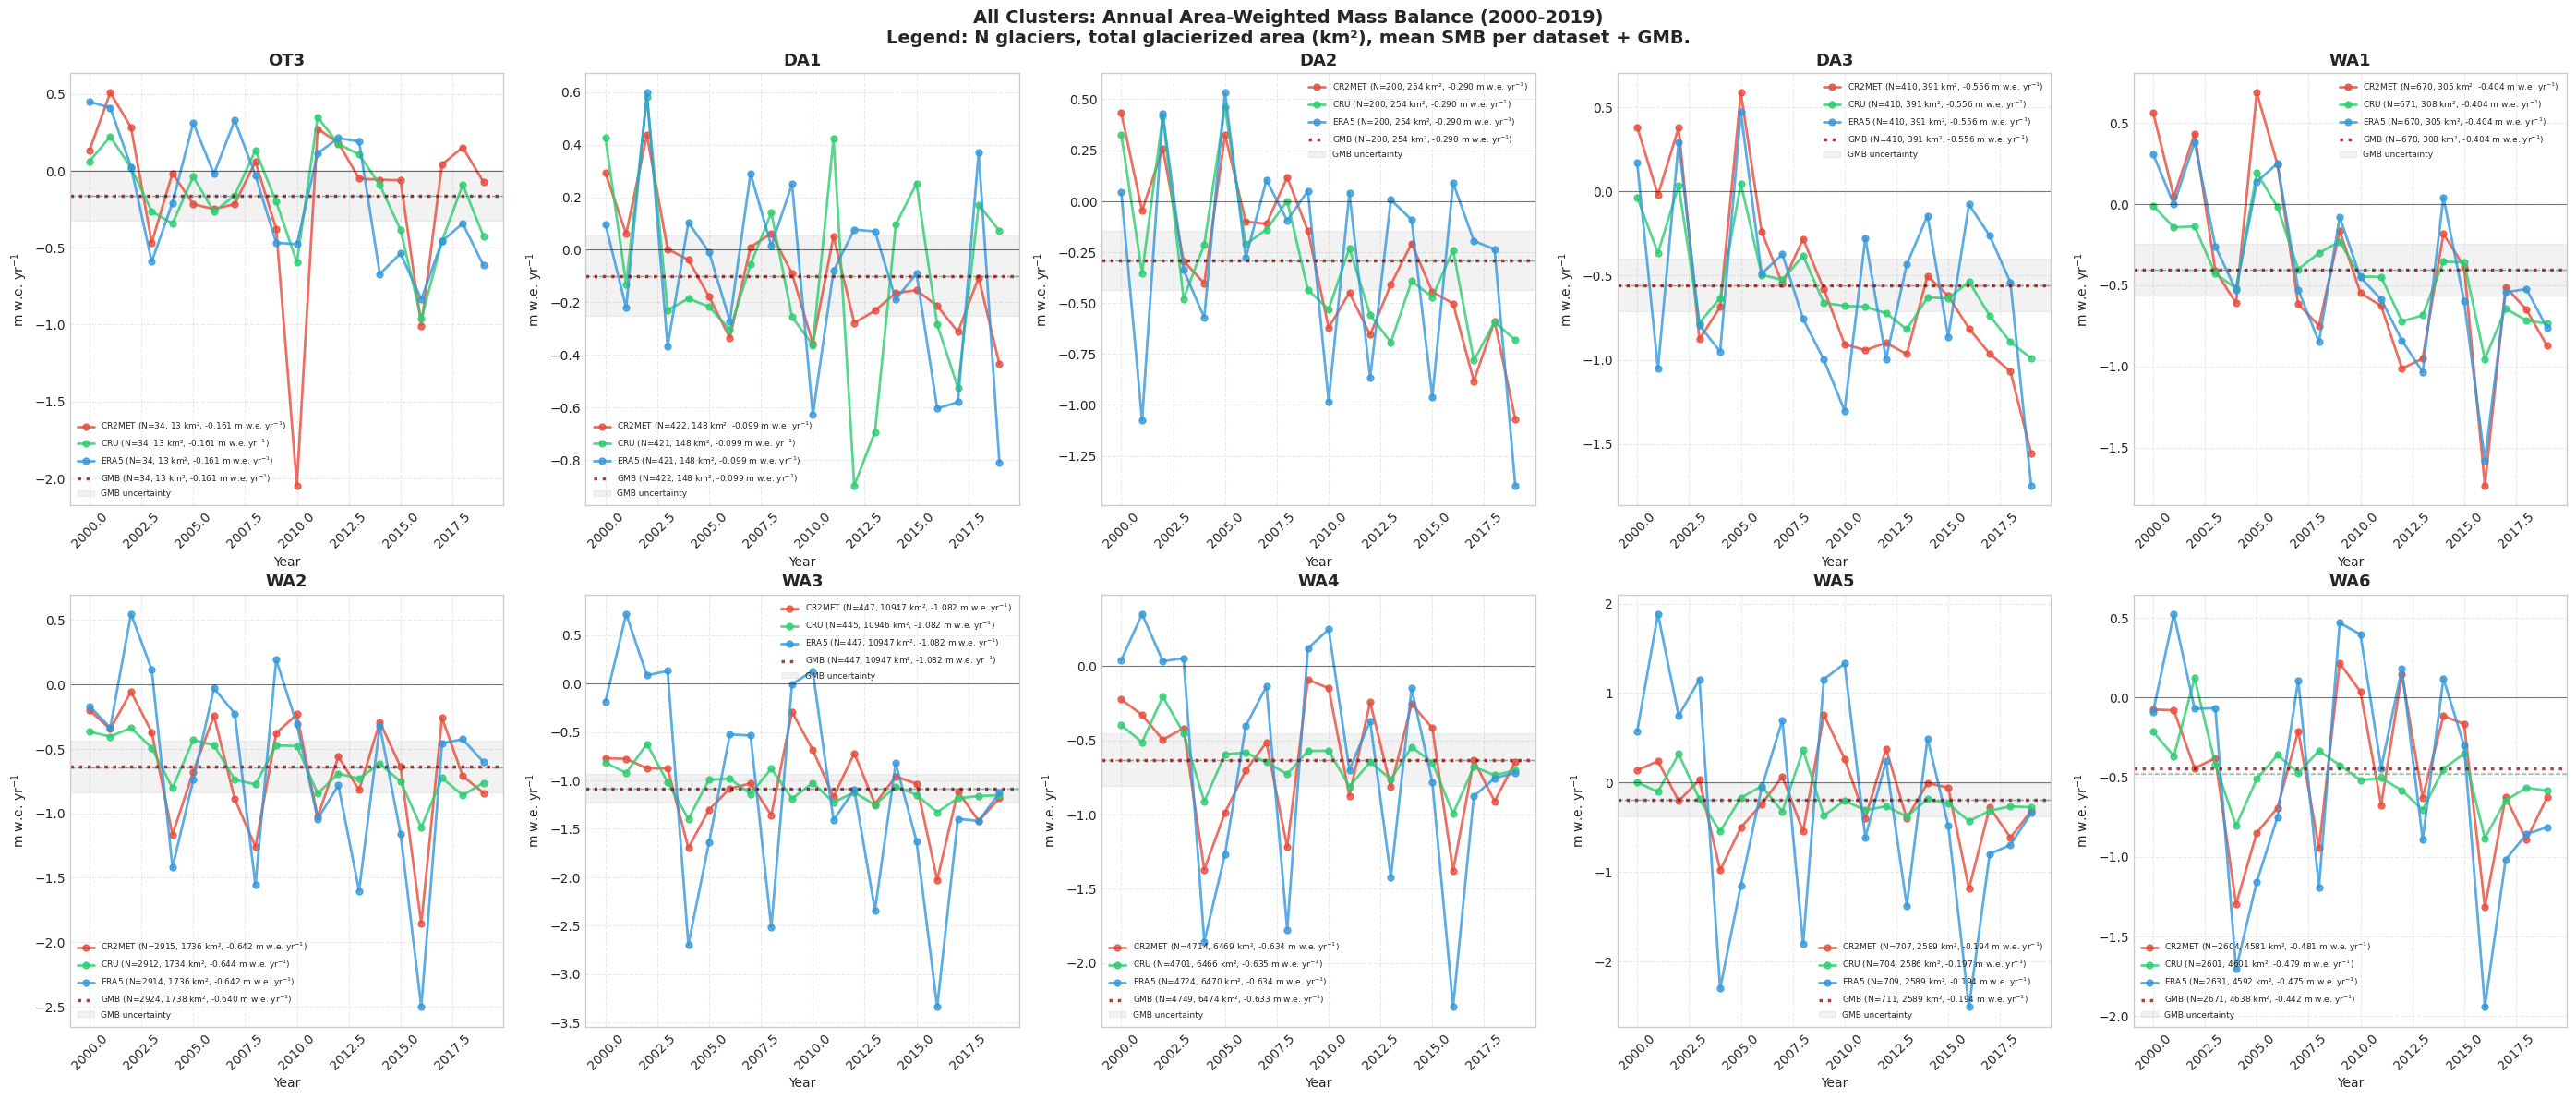

Mean annual SMB by cluster and dataset (m w.e. yr-1):
Cluster                       CR2MET                         CRU                        ERA5                         GMB
------------------------------------------------------------------------------------------------------------------------
OT3       -0.161 (N=  34,    13.2 km²)  -0.161 (N=  34,    13.2 km²)  -0.161 (N=  34,    13.2 km²)  -0.161 (N=  34,    13.2 km²)
DA1       -0.099 (N= 422,   148.1 km²)  -0.099 (N= 421,   148.1 km²)  -0.099 (N= 421,   148.1 km²)  -0.099 (N= 422,   148.1 km²)
DA2       -0.290 (N= 200,   253.9 km²)  -0.290 (N= 200,   253.9 km²)  -0.290 (N= 200,   253.9 km²)  -0.290 (N= 200,   253.9 km²)
DA3       -0.556 (N= 410,   390.6 km²)  -0.556 (N= 410,   390.6 km²)  -0.556 (N= 410,   390.6 km²)  -0.556 (N= 410,   390.6 km²)
WA1       -0.404 (N= 670,   304.5 km²)  -0.404 (N= 671,   307.8 km²)  -0.404 (N= 670,   304.5 km²)  -0.404 (N= 678,   307.9 km²)
WA2       -0.642 (N=2915,  1736.3 km²)  -0.644 (N=2912,  17

In [11]:
# ── Cell 8B: All clusters — annual mass balance timeseries ────────────────
# Same as Cell 8 but for all 10 clusters, 2 rows x 5 cols.
# Legend shows N glaciers, total glacierized area (km²), and mean SMB.
# Per Alexis: area is more informative than N alone in Patagonia.

cluster_annual = {}  # {dataset: {cluster: DataFrame}}
cluster_n      = {}  # {dataset: {cluster: int}}
cluster_area   = {}  # {dataset: {cluster: float km²}}
cluster_gmb    = {}  # {cluster: (gmb, gmb_err, n, area_km2)}

# ── Compute per-cluster annual SMB + area ─────────────────────────────────
for dataset in datasets:
    cluster_annual[dataset] = {}
    cluster_n[dataset]      = {}
    cluster_area[dataset]   = {}
    for cluster in clusters:
        mb_file = f'{base_path}{dataset}/{cluster}/mb.csv'
        if not os.path.exists(mb_file):
            continue
        mb_df     = pd.read_csv(mb_file).set_index('rgi_id')
        year_cols = mb_df.columns[:20]
        matched   = [g for g in glacier_lists[cluster]['with_gmb']
                     if g in mb_df.index]
        if not matched:
            continue
        weights   = geodetic_ref.loc[matched, 'area'].values
        annual_mb = [np.average(mb_df.loc[matched, col].values, weights=weights)
                     for col in year_cols]
        cluster_annual[dataset][cluster] = pd.DataFrame({
            'year': range(2000, 2020),
            'mb':   np.array(annual_mb) / 1000
        })
        cluster_n[dataset][cluster]    = len(matched)
        cluster_area[dataset][cluster] = weights.sum() / 1e6  # m² → km²

# ── Compute per-cluster GMB + area ────────────────────────────────────────
for cluster in clusters:
    matched  = glacier_lists[cluster]['with_gmb']
    weights  = geodetic_ref.loc[matched, 'area'].values
    gmb_vals = geodetic_ref.loc[matched, 'dmdtda'].values
    gmb_err  = geodetic_ref.loc[matched, 'err_dmdtda'].values
    cluster_gmb[cluster] = (
        np.average(gmb_vals, weights=weights),
        np.average(gmb_err,  weights=weights),
        len(matched),
        weights.sum() / 1e6  # km²
    )

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(28, 12), sharey=False)
axes_flat = axes.flatten()

for ax_idx, cluster in enumerate(clusters):
    ax = axes_flat[ax_idx]
    gmb_val, gmb_err_val, gmb_n, gmb_area = cluster_gmb[cluster]

    for dataset in datasets:
        if cluster not in cluster_annual.get(dataset, {}):
            continue
        df_ts   = cluster_annual[dataset][cluster]
        mean_mb = df_ts['mb'].mean()
        n       = cluster_n[dataset][cluster]
        area    = cluster_area[dataset][cluster]
        ax.plot(df_ts['year'], df_ts['mb'], 'o-',
                color=colors[dataset], linewidth=2, markersize=5,
                label=f'{dataset} (N={n}, {area:.0f} km², {mean_mb:.3f} m w.e. yr$^{{-1}}$)',
                alpha=0.8)
        ax.axhline(y=mean_mb, color=colors[dataset], linestyle='--',
                   linewidth=1, alpha=0.35)

    ax.axhline(y=gmb_val, color='darkred', linestyle=':', linewidth=2.5,
               label=f'GMB (N={gmb_n}, {gmb_area:.0f} km², {gmb_val:.3f} m w.e. yr$^{{-1}}$)',
               alpha=0.75)
    ax.axhspan(gmb_val - gmb_err_val, gmb_val + gmb_err_val,
               alpha=0.1, color='gray', label='GMB uncertainty')
    ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)

    ax.set_title(cluster, fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('m w.e. yr$^{-1}$', fontsize=10)
    ax.legend(loc='best', fontsize=6.5, framealpha=0.9)
    ax.grid(True, alpha=0.4, linestyle='--')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('All Clusters: Annual Area-Weighted Mass Balance (2000-2019)\n'
             'Legend: N glaciers, total glacierized area (km²), mean SMB per dataset + GMB.',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print('Mean annual SMB by cluster and dataset (m w.e. yr-1):')
print(f'{"Cluster":<8}', end='')
for ds in datasets + ['GMB']:
    print(f'{ds:>28}', end='')
print()
print('-' * (8 + 28 * (len(datasets) + 1)))
for cluster in clusters:
    print(f'{cluster:<8}', end='')
    for dataset in datasets:
        if cluster in cluster_annual.get(dataset, {}):
            mean_mb = cluster_annual[dataset][cluster]['mb'].mean()
            n       = cluster_n[dataset][cluster]
            area    = cluster_area[dataset][cluster]
            print(f'{mean_mb:>8.3f} (N={n:>4}, {area:>7.1f} km²)', end='')
        else:
            print(f'{"N/A":>28}', end='')
    gmb_val, gmb_err_val, gmb_n, gmb_area = cluster_gmb[cluster]
    print(f'{gmb_val:>8.3f} (N={gmb_n:>4}, {gmb_area:>7.1f} km²)')

# ── Chile-wide totals ──────────────────────────────────────────────────────
print('-' * (8 + 28 * (len(datasets) + 1)))
print(f'{"TOTAL":<8}', end='')
for dataset in datasets:
    total_n, total_area = 0, 0.0
    for cluster in clusters:
        if cluster in cluster_n.get(dataset, {}):
            total_n    += cluster_n[dataset][cluster]
            total_area += cluster_area[dataset][cluster]
    print(f'{"":>8}  (N={total_n:>5}, {total_area:>8.1f} km²)', end='')
total_gmb_n    = sum(cluster_gmb[c][2] for c in clusters)
total_gmb_area = sum(cluster_gmb[c][3] for c in clusters)
print(f'{"":>8}  (N={total_gmb_n:>5}, {total_gmb_area:>8.1f} km²)')

✓ Extracted 288 months for CR2MET
✓ Extracted 264 months for CRU
✓ Extracted 264 months for ERA5


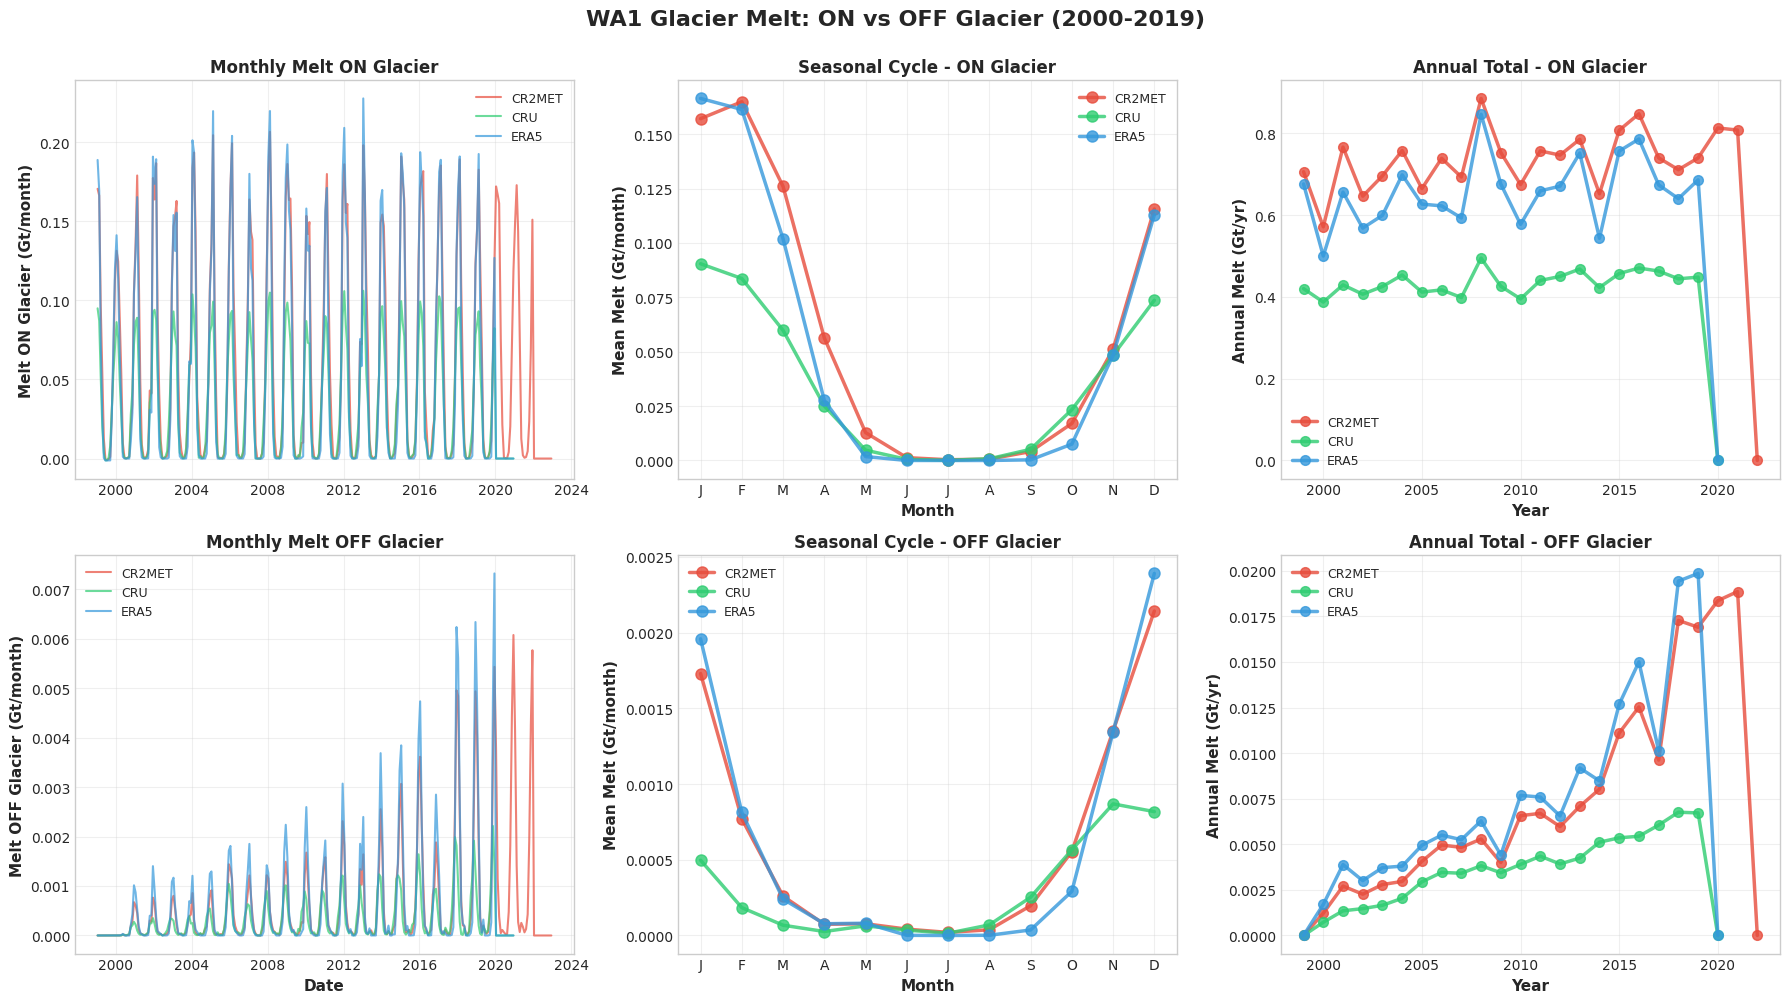


WA1 Melt Summary (2000-2019):
  CR2MET: ON=16.97 Gt (99.0%), OFF=0.17 Gt, peak month=F
  CRU: ON=9.13 Gt (99.2%), OFF=0.08 Gt, peak month=J
  ERA5: ON=13.81 Gt (98.9%), OFF=0.16 Gt, peak month=J


In [12]:
# ── Cell 9: WA1 monthly melt analysis — ON vs OFF glacier ─────────────────

wa1_nc = {}
for dataset in datasets:
    suffix  = 'TC' if dataset == 'CR2MET' else dataset
    nc_file = f'{base_path}{dataset}/WA1/run_output_2000_2019_hydro_{suffix}_WA1.nc'
    if os.path.exists(nc_file):
        wa1_nc[dataset] = xr.open_dataset(nc_file)
    else:
        print(f'  Missing NC: {dataset}/WA1')

def extract_monthly_melt(nc_dataset, dataset_name):
    if 'melt_on_glacier_monthly' not in nc_dataset or 'melt_off_glacier_monthly' not in nc_dataset:
        print(f'  Warning: No melt data for {dataset_name}')
        return None
    melt_on  = nc_dataset['melt_on_glacier_monthly'].sum(dim='rgi_id')
    melt_off = nc_dataset['melt_off_glacier_monthly'].sum(dim='rgi_id')
    years    = nc_dataset['time'].values
    rows = []
    for i, year in enumerate(years):
        for month in range(melt_on.shape[1]):
            try:
                on_val  = float(melt_on.isel(time=i,  month_2d=month).values) / 1e12
                off_val = float(melt_off.isel(time=i, month_2d=month).values) / 1e12
                rows.append({'date': pd.Timestamp(year=int(year), month=month+1, day=15),
                             'year': int(year), 'month': month+1,
                             'melt_on_Gt': on_val, 'melt_off_Gt': off_val,
                             'melt_total_Gt': on_val + off_val})
            except Exception:
                continue
    return pd.DataFrame(rows) if rows else None

wa1_monthly = {}
for dataset in datasets:
    if dataset in wa1_nc:
        monthly = extract_monthly_melt(wa1_nc[dataset], dataset)
        if monthly is not None:
            wa1_monthly[dataset] = monthly
            print(f'✓ Extracted {len(monthly)} months for {dataset}')

if wa1_monthly:
    months_lbl = ['J','F','M','A','M','J','J','A','S','O','N','D']
    fig, axes  = plt.subplots(2, 3, figsize=(18, 10))

    for row_idx, melt_col, row_label in [
        (0, 'melt_on_Gt',  'ON Glacier'),
        (1, 'melt_off_Gt', 'OFF Glacier')
    ]:
        ax = axes[row_idx, 0]
        for ds in datasets:
            if ds in wa1_monthly:
                ax.plot(wa1_monthly[ds]['date'], wa1_monthly[ds][melt_col],
                        '-', color=colors[ds], linewidth=1.5, label=ds, alpha=0.7)
        ax.set_ylabel(f'Melt {row_label} (Gt/month)', fontsize=11, fontweight='bold')
        ax.set_title(f'Monthly Melt {row_label}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        if row_idx == 1:
            ax.set_xlabel('Date', fontsize=11, fontweight='bold')

        ax = axes[row_idx, 1]
        for ds in datasets:
            if ds in wa1_monthly:
                seasonal = wa1_monthly[ds].groupby('month')[melt_col].mean()
                ax.plot(range(1, 13), seasonal, 'o-',
                        color=colors[ds], linewidth=2.5, markersize=8,
                        label=ds, alpha=0.8)
        ax.set_xlabel('Month', fontsize=11, fontweight='bold')
        ax.set_ylabel('Mean Melt (Gt/month)', fontsize=11, fontweight='bold')
        ax.set_title(f'Seasonal Cycle - {row_label}', fontsize=12, fontweight='bold')
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(months_lbl)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

        ax = axes[row_idx, 2]
        for ds in datasets:
            if ds in wa1_monthly:
                annual = wa1_monthly[ds].groupby('year')[melt_col].sum()
                ax.plot(annual.index, annual.values, 'o-',
                        color=colors[ds], linewidth=2.5, markersize=7,
                        label=ds, alpha=0.8)
        ax.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax.set_ylabel('Annual Melt (Gt/yr)', fontsize=11, fontweight='bold')
        ax.set_title(f'Annual Total - {row_label}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle('WA1 Glacier Melt: ON vs OFF Glacier (2000-2019)',
                 fontsize=16, fontweight='bold', y=0.999)
    plt.tight_layout()
    plt.show()

    print('\nWA1 Melt Summary (2000-2019):')
    for ds in datasets:
        if ds not in wa1_monthly:
            continue
        tot_on  = wa1_monthly[ds]['melt_on_Gt'].sum()
        tot_off = wa1_monthly[ds]['melt_off_Gt'].sum()
        tot     = tot_on + tot_off
        peak    = wa1_monthly[ds].groupby('month')['melt_total_Gt'].mean().idxmax()
        print(f'  {ds}: ON={tot_on:.2f} Gt ({tot_on/tot*100:.1f}%), '
              f'OFF={tot_off:.2f} Gt, peak month={months_lbl[peak-1]}')
else:
    print('No monthly melt data available')

Glacier areas by cluster (km²):
  OT3: 13.2 km²
  DA1: 148.1 km²
  DA2: 253.9 km²
  DA3: 390.6 km²
  WA1: 307.9 km²
  WA2: 1737.9 km²
  WA3: 10946.5 km²
  WA4: 6474.0 km²
  WA5: 2588.7 km²
  WA6: 4638.4 km²
Generating Option 1: m³/s...


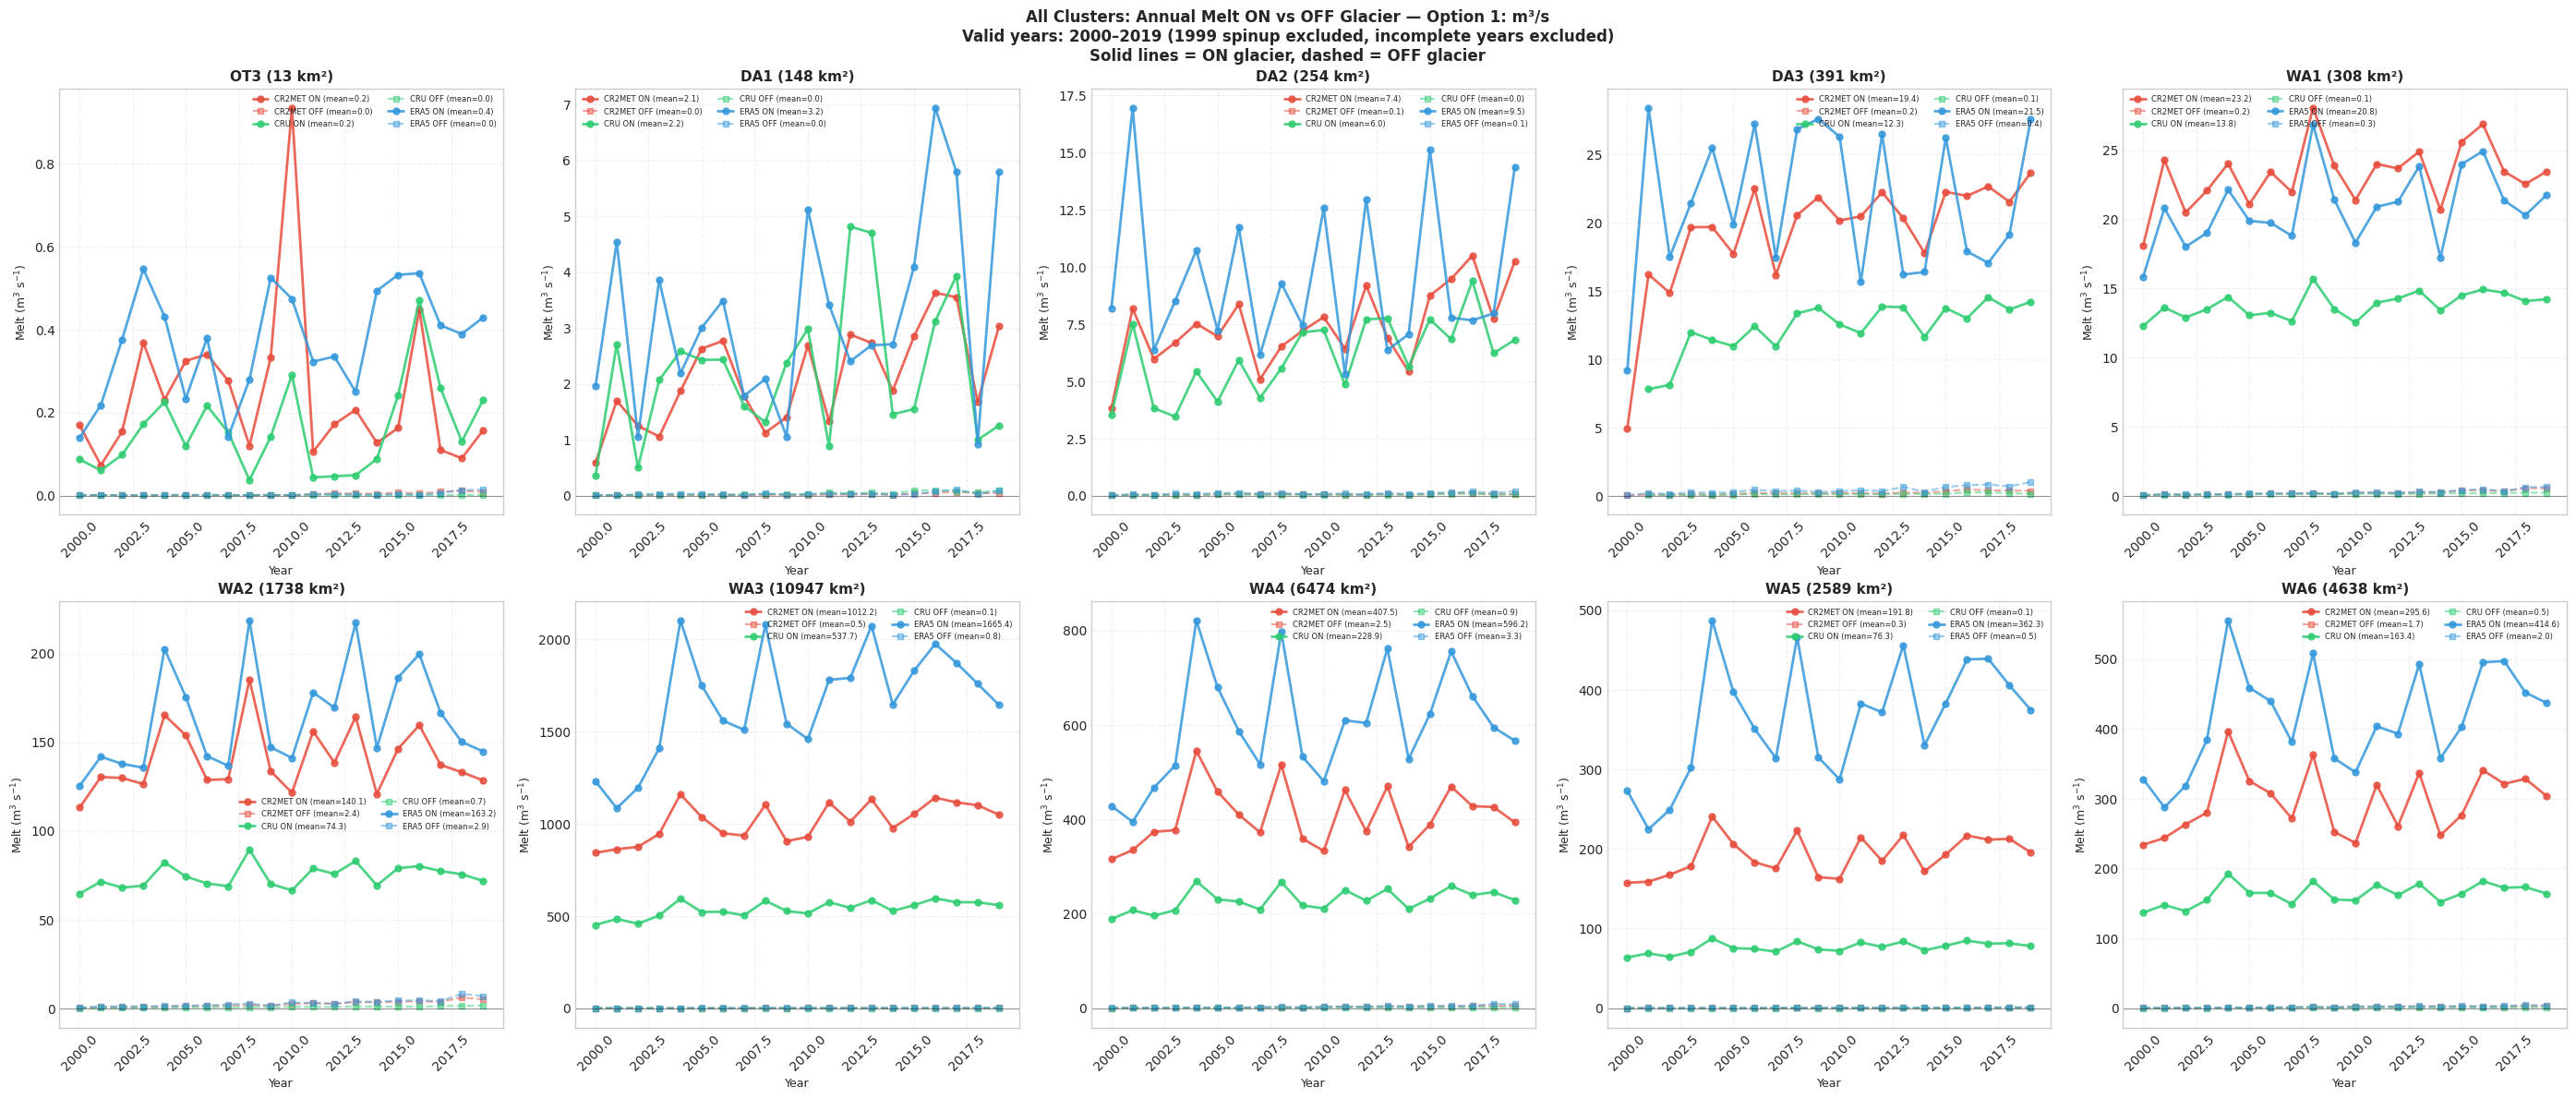

Generating Option 2: mm/yr over glacier area...


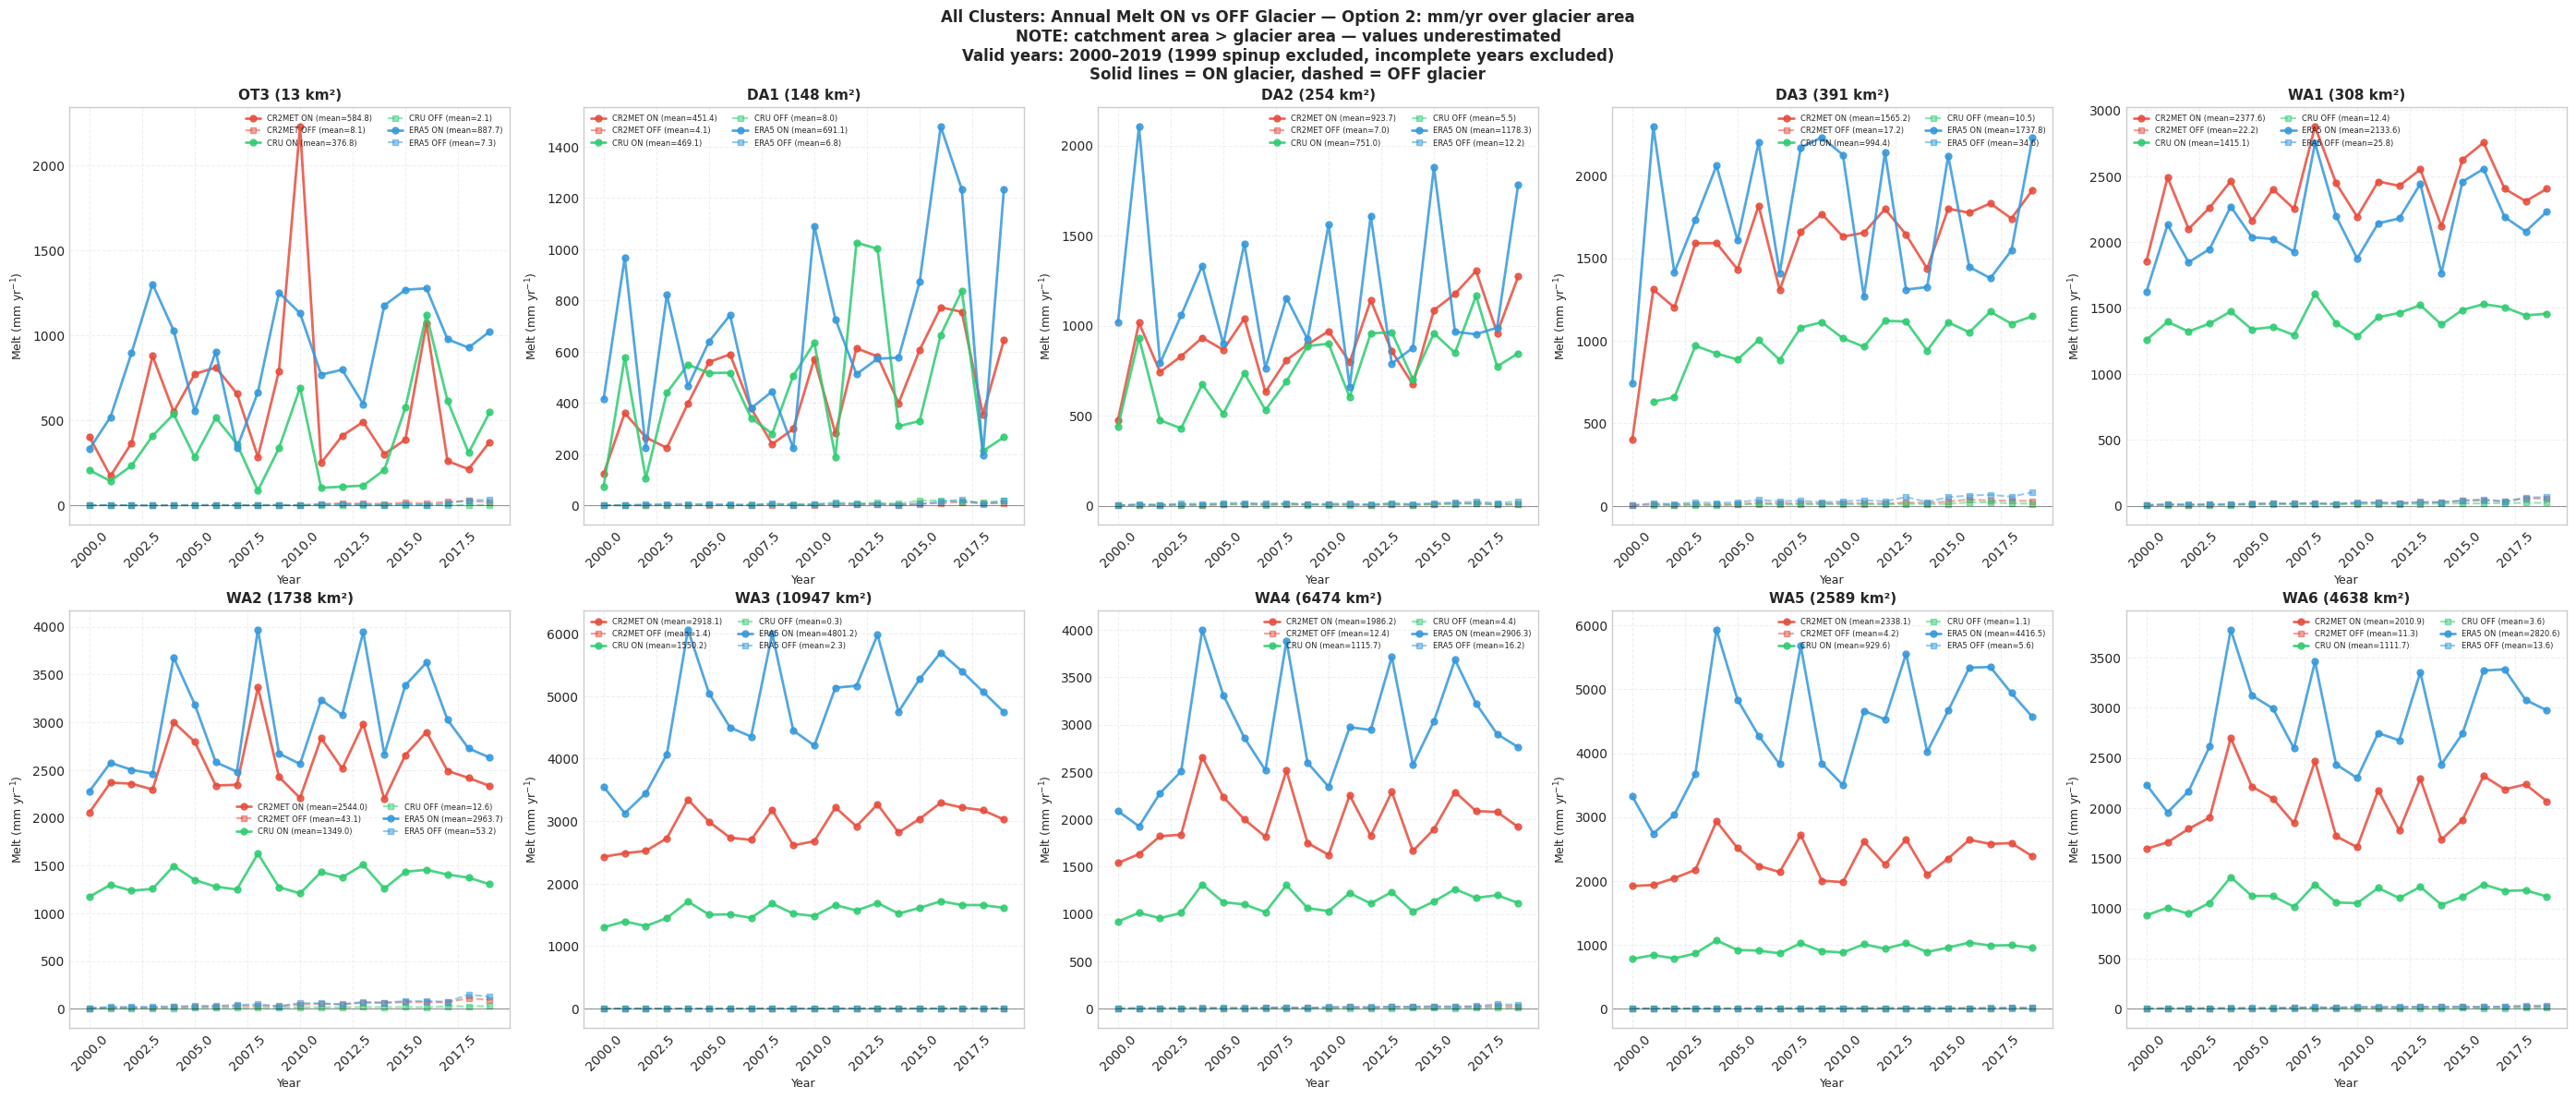


Option 3 (mm over catchment area) — NOT IMPLEMENTED
  Requires extracting flowline_catchments.tar.gz per glacier.
  Ask Alexis if catchment areas are already computed.

Mean annual melt (2000–2019):
Cluster  Area(km²)  CR2MET ON(m3s) CR2MET OFF(m3s)     CRU ON(m3s)    CRU OFF(m3s)    ERA5 ON(m3s)   ERA5 OFF(m3s)
------------------------------------------------------------------------------------------------------------------
OT3           13.2             0.2             0.0             0.2             0.0             0.4             0.0
DA1          148.1             2.1             0.0             2.2             0.0             3.2             0.0
DA2          253.9             7.4             0.1             6.0             0.0             9.5             0.1
DA3          390.6            19.4             0.2            12.3             0.1            21.5             0.4
WA1          307.9            23.2             0.2            13.8             0.1            20.8            

In [13]:
# ── Cell 9: All-cluster melt ON vs OFF glacier — annual timeseries ─────────
# Valid years: exclude 1999 (spinup) and any year with 0.0 Gt (incomplete).
# Safe window for all datasets: 2000-2019.
#
# THREE UNIT OPTIONS:
#   Option 1: m³/s  — no area needed, standard hydrology
#   Option 2: mm over glacier area (rgi_area_km2) — approximation
#   Option 3: mm over catchment area — NOT IMPLEMENTED
#             requires flowline_catchments.tar.gz extraction per glacier

import glob

# ── Valid year filter ─────────────────────────────────────────────────────
VALID_YEAR_MIN = 2000
VALID_YEAR_MAX = 2019

# ── Load all NetCDF files ─────────────────────────────────────────────────
all_nc = {}
for dataset in datasets:
    all_nc[dataset] = {}
    for cluster in clusters:
        suffix  = 'TC' if dataset == 'CR2MET' else dataset
        nc_file = f'{base_path}{dataset}/{cluster}/run_output_2000_2019_hydro_{suffix}_{cluster}.nc'
        if os.path.exists(nc_file):
            all_nc[dataset][cluster] = xr.open_dataset(nc_file)

# ── Load glacier areas per cluster ───────────────────────────────────────
cluster_glacier_area_km2 = {}
for cluster in clusters:
    stats_file = glob.glob(
        f'{base_path}CR2MET/**/glacier_statistics__{cluster}.csv',
        recursive=True)
    if stats_file:
        gs   = pd.read_csv(stats_file[0])
        area = gs['rgi_area_km2'].sum()
        cluster_glacier_area_km2[cluster] = area
    else:
        cluster_glacier_area_km2[cluster] = np.nan
        print(f'  WARNING: no glacier_statistics for {cluster}')

print('Glacier areas by cluster (km²):')
for cluster, area in cluster_glacier_area_km2.items():
    print(f'  {cluster}: {area:.1f} km²')

# ── Conversion factors ────────────────────────────────────────────────────
GT_TO_M3S = 1e9 / 31_557_600

def gt_to_mm(gt_per_yr, area_km2):
    return gt_per_yr * 1e9 / (area_km2 * 1e6) * 1000

# ── Extract annual melt with valid year filter ────────────────────────────
annual_melt = {}
for dataset in datasets:
    annual_melt[dataset] = {}
    for cluster in clusters:
        if cluster not in all_nc.get(dataset, {}):
            continue
        nc = all_nc[dataset][cluster]
        if 'melt_on_glacier_monthly' not in nc or \
           'melt_off_glacier_monthly' not in nc:
            continue
        years    = nc['time'].values
        melt_on  = nc['melt_on_glacier_monthly'].sum(
                       dim='rgi_id').sum(dim='month_2d').values / 1e12
        melt_off = nc['melt_off_glacier_monthly'].sum(
                       dim='rgi_id').sum(dim='month_2d').values / 1e12

        # Apply valid year filter: exclude spinup + incomplete years
        mask = (years >= VALID_YEAR_MIN) & \
               (years <= VALID_YEAR_MAX) & \
               (melt_on > 0) & \
               (melt_off > 0)

        years    = years[mask]
        melt_on  = melt_on[mask]
        melt_off = melt_off[mask]
        area     = cluster_glacier_area_km2.get(cluster, np.nan)

        annual_melt[dataset][cluster] = pd.DataFrame({
            'year':         years,
            'melt_on_Gt':   melt_on,
            'melt_off_Gt':  melt_off,
            'melt_on_m3s':  melt_on  * GT_TO_M3S,
            'melt_off_m3s': melt_off * GT_TO_M3S,
            'melt_on_mm':   gt_to_mm(melt_on,  area),
            'melt_off_mm':  gt_to_mm(melt_off, area),
        })

# ── Plotting function ─────────────────────────────────────────────────────
def plot_all_cluster_melt(unit_col_on, unit_col_off, ylabel, title_suffix):
    fig, axes = plt.subplots(2, 5, figsize=(28, 12), sharey=False)
    axes_flat = axes.flatten()

    for ax_idx, cluster in enumerate(clusters):
        ax   = axes_flat[ax_idx]
        area = cluster_glacier_area_km2.get(cluster, np.nan)

        for dataset in datasets:
            if cluster not in annual_melt.get(dataset, {}):
                continue
            d        = annual_melt[dataset][cluster]
            mean_on  = d[unit_col_on].mean()
            mean_off = d[unit_col_off].mean()
            ax.plot(d['year'], d[unit_col_on], 'o-',
                    color=colors[dataset], linewidth=2, markersize=5,
                    label=f'{dataset} ON (mean={mean_on:.1f})',
                    alpha=0.85)
            ax.plot(d['year'], d[unit_col_off], 's--',
                    color=colors[dataset], linewidth=1.5, markersize=5,
                    label=f'{dataset} OFF (mean={mean_off:.1f})',
                    alpha=0.5)

        area_str = f'{area:.0f} km²' if not np.isnan(area) else 'area N/A'
        ax.set_title(f'{cluster} ({area_str})', fontsize=11, fontweight='bold')
        ax.set_xlabel('Year', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.legend(fontsize=6, ncol=2, framealpha=0.8)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(axis='x', rotation=45)
        ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.4)

    plt.suptitle(
        f'All Clusters: Annual Melt ON vs OFF Glacier — {title_suffix}\n'
        f'Valid years: {VALID_YEAR_MIN}–{VALID_YEAR_MAX} '
        f'(1999 spinup excluded, incomplete years excluded)\n'
        'Solid lines = ON glacier, dashed = OFF glacier',
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ── Option 1: m³/s ────────────────────────────────────────────────────────
print('Generating Option 1: m³/s...')
plot_all_cluster_melt(
    unit_col_on  = 'melt_on_m3s',
    unit_col_off = 'melt_off_m3s',
    ylabel       = 'Melt (m$^{3}$ s$^{-1}$)',
    title_suffix = 'Option 1: m³/s'
)

# ── Option 2: mm over glacier area ────────────────────────────────────────
print('Generating Option 2: mm/yr over glacier area...')
plot_all_cluster_melt(
    unit_col_on  = 'melt_on_mm',
    unit_col_off = 'melt_off_mm',
    ylabel       = 'Melt (mm yr$^{-1}$)',
    title_suffix = 'Option 2: mm/yr over glacier area\n'
                   'NOTE: catchment area > glacier area — values underestimated'
)

# ── Option 3 note ─────────────────────────────────────────────────────────
print('\nOption 3 (mm over catchment area) — NOT IMPLEMENTED')
print('  Requires extracting flowline_catchments.tar.gz per glacier.')
print('  Ask Alexis if catchment areas are already computed.')

# ── Summary table ─────────────────────────────────────────────────────────
print(f'\nMean annual melt ({VALID_YEAR_MIN}–{VALID_YEAR_MAX}):')
print(f'{"Cluster":<8}{"Area(km²)":>10}', end='')
for ds in datasets:
    print(f'{ds+" ON(m3s)":>16}{ds+" OFF(m3s)":>16}', end='')
print()
print('-' * (18 + 32 * len(datasets)))
for cluster in clusters:
    area = cluster_glacier_area_km2.get(cluster, np.nan)
    print(f'{cluster:<8}{area:>10.1f}', end='')
    for dataset in datasets:
        if cluster in annual_melt.get(dataset, {}):
            d = annual_melt[dataset][cluster]
            print(f'{d["melt_on_m3s"].mean():>16.1f}'
                  f'{d["melt_off_m3s"].mean():>16.1f}', end='')
        else:
            print(f'{"N/A":>16}{"N/A":>16}', end='')
    print()

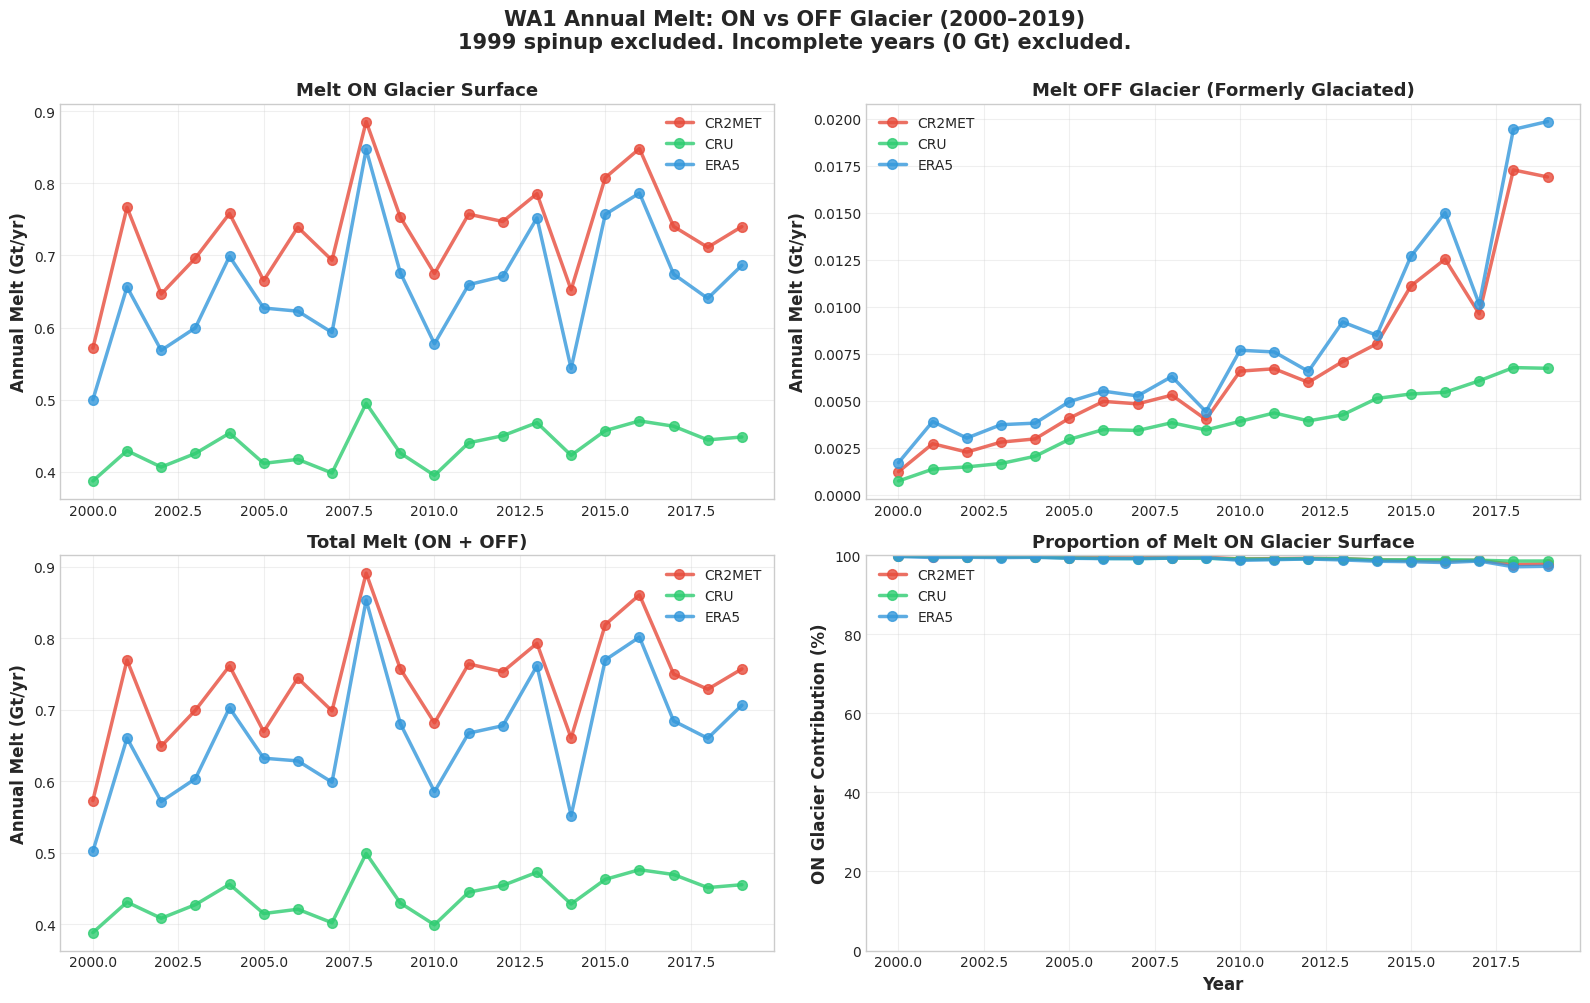


WA1 Annual Melt Summary (2000–2019):
  CR2MET (N=20 yrs): ON=0.73 Gt/yr (99.1%), OFF=0.01, Total=0.74
  CRU (N=20 yrs): ON=0.44 Gt/yr (99.1%), OFF=0.00, Total=0.44
  ERA5 (N=20 yrs): ON=0.66 Gt/yr (98.8%), OFF=0.01, Total=0.66


In [14]:
# ── Cell 10 Part 1: WA1 annual melt ON vs OFF glacier ─────────────────────
# Valid years: 2000-2019, excluding 1999 (spinup) and incomplete years (0 Gt)

VALID_YEAR_MIN = 2000
VALID_YEAR_MAX = 2019

if 'WA1' in all_nc.get('CR2MET', {}):  # check NetCDFs loaded
    wa1_annual_melt = {}
    for dataset in datasets:
        if dataset not in all_nc or 'WA1' not in all_nc[dataset]:
            continue
        nc = all_nc[dataset]['WA1']
        if 'melt_on_glacier_monthly' not in nc or \
           'melt_off_glacier_monthly' not in nc:
            continue

        years    = nc['time'].values
        melt_on  = nc['melt_on_glacier_monthly'].sum(
                       dim='rgi_id').sum(dim='month_2d').values / 1e12
        melt_off = nc['melt_off_glacier_monthly'].sum(
                       dim='rgi_id').sum(dim='month_2d').values / 1e12

        # Valid year filter
        mask     = (years >= VALID_YEAR_MIN) & \
                   (years <= VALID_YEAR_MAX) & \
                   (melt_on > 0) & (melt_off > 0)
        years    = years[mask]
        melt_on  = melt_on[mask]
        melt_off = melt_off[mask]

        wa1_annual_melt[dataset] = pd.DataFrame({
            'year':          years,
            'melt_on_Gt':    melt_on,
            'melt_off_Gt':   melt_off,
            'melt_total_Gt': melt_on + melt_off,
        })

    if wa1_annual_melt:
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        panels = [
            (axes[0, 0], 'melt_on_Gt',    'Melt ON Glacier Surface'),
            (axes[0, 1], 'melt_off_Gt',   'Melt OFF Glacier (Formerly Glaciated)'),
            (axes[1, 0], 'melt_total_Gt', 'Total Melt (ON + OFF)'),
        ]
        for ax, col, title in panels:
            for ds in datasets:
                if ds not in wa1_annual_melt:
                    continue
                d = wa1_annual_melt[ds]
                ax.plot(d['year'], d[col], 'o-',
                        color=colors[ds], linewidth=2.5, markersize=7,
                        label=ds, alpha=0.8)
            ax.set_ylabel('Annual Melt (Gt/yr)', fontsize=12, fontweight='bold')
            ax.set_title(title, fontsize=13, fontweight='bold')
            ax.legend(fontsize=10)
            ax.grid(alpha=0.3)

        ax = axes[1, 1]
        for ds in datasets:
            if ds not in wa1_annual_melt:
                continue
            d      = wa1_annual_melt[ds]
            pct_on = (d['melt_on_Gt'] / d['melt_total_Gt']) * 100
            ax.plot(d['year'], pct_on, 'o-',
                    color=colors[ds], linewidth=2.5, markersize=7,
                    label=ds, alpha=0.8)
        ax.set_xlabel('Year', fontsize=12, fontweight='bold')
        ax.set_ylabel('ON Glacier Contribution (%)', fontsize=12, fontweight='bold')
        ax.set_title('Proportion of Melt ON Glacier Surface',
                     fontsize=13, fontweight='bold')
        ax.set_ylim([0, 100])
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)

        plt.suptitle(
            f'WA1 Annual Melt: ON vs OFF Glacier ({VALID_YEAR_MIN}–{VALID_YEAR_MAX})\n'
            '1999 spinup excluded. Incomplete years (0 Gt) excluded.',
            fontsize=15, fontweight='bold', y=0.999)
        plt.tight_layout()
        plt.show()

        print(f'\nWA1 Annual Melt Summary ({VALID_YEAR_MIN}–{VALID_YEAR_MAX}):')
        for ds in datasets:
            if ds not in wa1_annual_melt:
                continue
            d        = wa1_annual_melt[ds]
            mean_on  = d['melt_on_Gt'].mean()
            mean_off = d['melt_off_Gt'].mean()
            mean_tot = d['melt_total_Gt'].mean()
            n_years  = len(d)
            print(f'  {ds} (N={n_years} yrs): '
                  f'ON={mean_on:.2f} Gt/yr ({mean_on/mean_tot*100:.1f}%), '
                  f'OFF={mean_off:.2f}, Total={mean_tot:.2f}')
    else:
        print('No annual melt data available')
else:
    print('NetCDF files not loaded — rerun Cell 9 first')

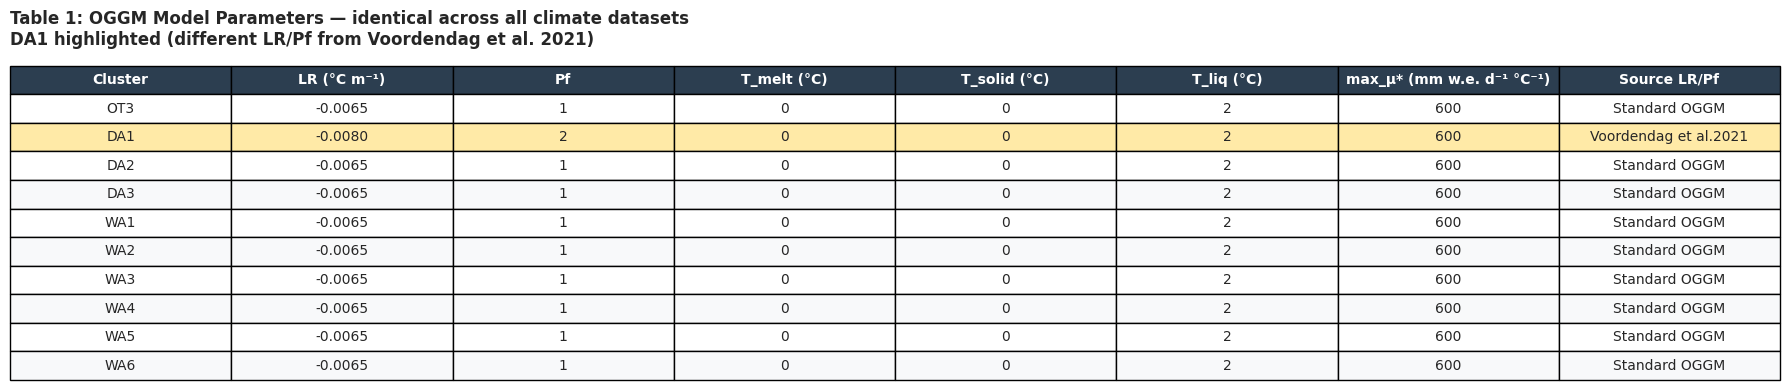

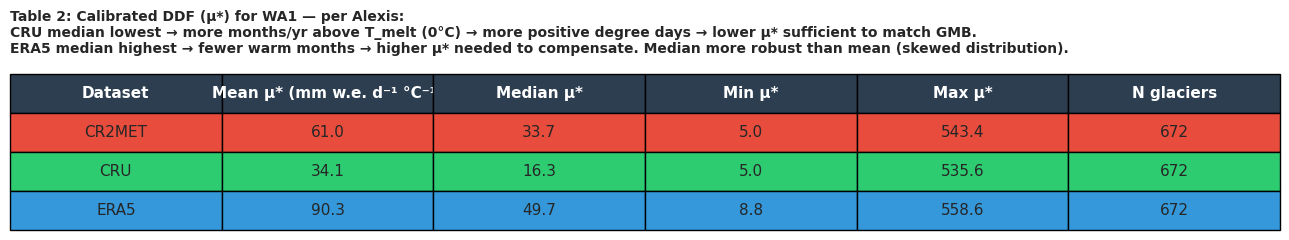


μ* interpretation for WA1:
  Higher μ* = fewer months above T_melt = COLDER climate input
  Lower μ*  = more months above T_melt  = WARMER climate input
  CR2MET  : mean=  61.0, median=  33.7
  CRU     : mean=  34.1, median=  16.3
  ERA5    : mean=  90.3, median=  49.7


In [15]:
# ── Cell 10 Part 2: Calibration parameters tables ─────────────────────────
# Table 1: Fixed OGGM parameters (all clusters)
# Table 2: mu_star per dataset for WA1
# Per Alexis: CRU median lowest (more warm months → fewer PDD needed)
#             ERA5 median highest (fewer warm months → more PDD needed)

lr_pf = pd.read_csv(
    '/Users/milliespencer/Desktop/CR2_OGGM_Paper/'
    'files_chile_OGGM_climate_comparison/LR_Pf.csv')

# ── Load mu_star for WA1 per dataset ──────────────────────────────────────
mu_star_stats = {}
for dataset in datasets:
    stats_file = glob.glob(
        f'{base_path}{dataset}/**/glacier_statistics__WA1.csv',
        recursive=True)
    if stats_file:
        gs = pd.read_csv(stats_file[0])
        mu = gs['mu_star_glacierwide'].dropna()
        if 'rgi_area_km2' in gs.columns:
            weights = gs.loc[mu.index, 'rgi_area_km2']
            mu_mean = np.average(mu, weights=weights)
        else:
            mu_mean = mu.mean()
        mu_star_stats[dataset] = {
            'mean':   mu_mean,
            'median': mu.median(),
            'min':    mu.min(),
            'max':    mu.max(),
            'n':      len(mu)
        }

# ── Table 1: Fixed parameters (all clusters) ──────────────────────────────
fig, ax = plt.subplots(figsize=(18, 4))
ax.axis('off')

table_rows = []
for _, row in lr_pf.iterrows():
    table_rows.append({
        'Cluster':                     row['Cluster'],
        'LR (°C m⁻¹)':                f"{row['LR']:.4f}",
        'Pf':                          f"{row['Pf']:.0f}",
        'T_melt (°C)':                 '0',
        'T_solid (°C)':                '0',
        'T_liq (°C)':                  '2',
        'max_μ* (mm w.e. d⁻¹ °C⁻¹)':  '600',
        'Source LR/Pf': row['fuente'] if pd.notna(row['fuente'])
                        else 'Standard OGGM',
    })
param_table = pd.DataFrame(table_rows)

tbl = ax.table(cellText=param_table.values.tolist(),
               colLabels=list(param_table.columns),
               cellLoc='center', loc='center',
               bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)

for j in range(len(param_table.columns)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(table_rows) + 1):
    color = '#ffeaa7' if lr_pf.iloc[i-1]['Cluster'] == 'DA1' else \
            '#f8f9fa' if i % 2 == 0 else 'white'
    for j in range(len(param_table.columns)):
        tbl[i, j].set_facecolor(color)

ax.set_title('Table 1: OGGM Model Parameters — identical across all climate datasets\n'
             'DA1 highlighted (different LR/Pf from Voordendag et al. 2021)',
             fontsize=12, fontweight='bold', pad=15, loc='left')
plt.tight_layout()
plt.show()

# ── Table 2: mu_star per dataset for WA1 ──────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 2.5))
ax.axis('off')

mu_rows = []
for dataset in datasets:
    if dataset in mu_star_stats:
        s = mu_star_stats[dataset]
        mu_rows.append([
            dataset,
            f"{s['mean']:.1f}",
            f"{s['median']:.1f}",
            f"{s['min']:.1f}",
            f"{s['max']:.1f}",
            f"{s['n']}",
        ])

mu_col_labels = ['Dataset',
                 'Mean μ* (mm w.e. d⁻¹ °C⁻¹)',
                 'Median μ*',
                 'Min μ*',
                 'Max μ*',
                 'N glaciers']

tbl2 = ax.table(cellText=mu_rows,
                colLabels=mu_col_labels,
                cellLoc='center', loc='center',
                bbox=[0, 0, 1, 1])
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(11)

for j in range(len(mu_col_labels)):
    tbl2[0, j].set_facecolor('#2c3e50')
    tbl2[0, j].set_text_props(color='white', fontweight='bold')
for i, dataset in enumerate(datasets, start=1):
    for j in range(len(mu_col_labels)):
        tbl2[i, j].set_facecolor(colors[dataset])

ax.set_title(
    'Table 2: Calibrated DDF (μ*) for WA1 — per Alexis:\n'
    'CRU median lowest → more months/yr above T_melt (0°C) → more positive degree days '
    '→ lower μ* sufficient to match GMB.\n'
    'ERA5 median highest → fewer warm months → higher μ* needed to compensate. '
    'Median more robust than mean (skewed distribution).',
    fontsize=10, fontweight='bold', pad=15, loc='left')
plt.tight_layout()
plt.show()

print('\nμ* interpretation for WA1:')
print('  Higher μ* = fewer months above T_melt = COLDER climate input')
print('  Lower μ*  = more months above T_melt  = WARMER climate input')
for ds in datasets:
    if ds in mu_star_stats:
        s = mu_star_stats[ds]
        print(f'  {ds:<8}: mean={s["mean"]:>6.1f}, median={s["median"]:>6.1f}')

ERA5 has the highest mu_star (meaning OGGM needed a higher melt factor to match Hugonnet), which implies ERA5 has the coldest temperatures over WA1. CRU has the lowest mu_star, meaning it has the warmest temperatures. This explains exactly why CRU shows the lowest melt in the figures — warmer input temperatures but lower mu_star means less melt per degree above threshold.

Put differently: with CRU, there are  more months per year with temperatures above T_melt (0°C) → melt occurs more frequently → a lower mu_star is sufficient to match the observed GMB because there are already many positive degree days
ERA5: fewer months above T_melt → melt occurs less frequently → needs a higher mu_star to compensate and still match the same observed mass loss
CR2MET: intermediate

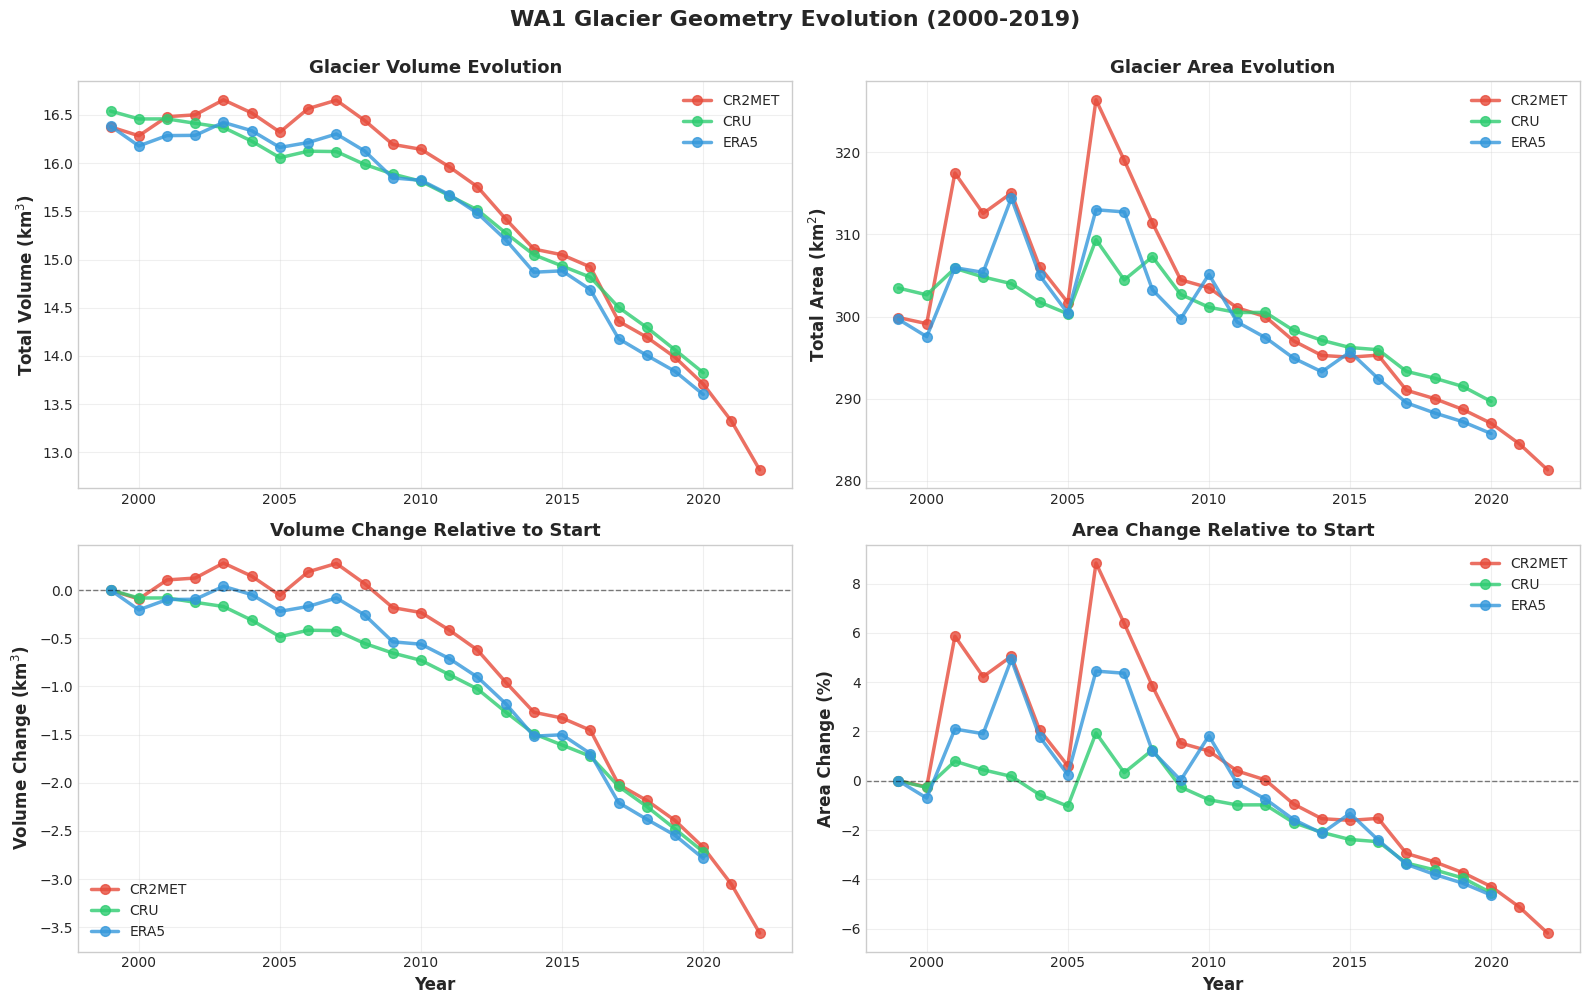


WA1 Geometry Change Summary:
  CR2MET: Vol loss=3.56 km3 (21.7%), Area loss=18.53 km2 (6.2%)
  CRU: Vol loss=2.72 km3 (16.4%), Area loss=13.80 km2 (4.5%)
  ERA5: Vol loss=2.78 km3 (17.0%), Area loss=13.90 km2 (4.6%)


In [16]:
# ── Cell 11: WA1 glacier geometry evolution ────────────────────────────────

if wa1_nc:
    wa1_geometry = {}
    for dataset in datasets:
        if dataset not in wa1_nc:
            continue
        nc = wa1_nc[dataset]
        wa1_geometry[dataset] = pd.DataFrame({
            'year':       nc['time'].values,
            'volume_km3': (nc['volume'].sum(dim='rgi_id') / 1e9).values,
            'area_km2':   (nc['area'].sum(dim='rgi_id')   / 1e6).values
        })

    if wa1_geometry:
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))

        for ax, col, ylabel, title in [
            (axes[0,0], 'volume_km3', 'Total Volume (km$^{3}$)', 'Glacier Volume Evolution'),
            (axes[0,1], 'area_km2',   'Total Area (km$^{2}$)',   'Glacier Area Evolution'),
        ]:
            for ds in datasets:
                if ds in wa1_geometry:
                    d = wa1_geometry[ds]
                    ax.plot(d['year'], d[col], 'o-',
                            color=colors[ds], linewidth=2.5, markersize=7,
                            label=ds, alpha=0.8)
            ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
            ax.set_title(title, fontsize=13, fontweight='bold')
            ax.legend(fontsize=10)
            ax.grid(alpha=0.3)

        ax = axes[1, 0]
        for ds in datasets:
            if ds in wa1_geometry:
                d = wa1_geometry[ds]
                ax.plot(d['year'], d['volume_km3'] - d['volume_km3'].iloc[0], 'o-',
                        color=colors[ds], linewidth=2.5, markersize=7,
                        label=ds, alpha=0.8)
        ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
        ax.set_xlabel('Year', fontsize=12, fontweight='bold')
        ax.set_ylabel('Volume Change (km$^{3}$)', fontsize=12, fontweight='bold')
        ax.set_title('Volume Change Relative to Start', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)

        ax = axes[1, 1]
        for ds in datasets:
            if ds in wa1_geometry:
                d   = wa1_geometry[ds]
                pct = (d['area_km2'] - d['area_km2'].iloc[0]) / d['area_km2'].iloc[0] * 100
                ax.plot(d['year'], pct, 'o-',
                        color=colors[ds], linewidth=2.5, markersize=7,
                        label=ds, alpha=0.8)
        ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
        ax.set_xlabel('Year', fontsize=12, fontweight='bold')
        ax.set_ylabel('Area Change (%)', fontsize=12, fontweight='bold')
        ax.set_title('Area Change Relative to Start', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)

        plt.suptitle('WA1 Glacier Geometry Evolution (2000-2019)',
                     fontsize=16, fontweight='bold', y=0.999)
        plt.tight_layout()
        plt.show()

        print('\nWA1 Geometry Change Summary:')
        for ds in datasets:
            if ds not in wa1_geometry:
                continue
            d         = wa1_geometry[ds]
            vol_loss  = d['volume_km3'].iloc[0] - d['volume_km3'].iloc[-1]
            vol_pct   = vol_loss / d['volume_km3'].iloc[0] * 100
            area_loss = d['area_km2'].iloc[0] - d['area_km2'].iloc[-1]
            area_pct  = area_loss / d['area_km2'].iloc[0] * 100
            print(f'  {ds}: Vol loss={vol_loss:.2f} km3 ({vol_pct:.1f}%), '
                  f'Area loss={area_loss:.2f} km2 ({area_pct:.1f}%)')
    else:
        print('No geometry data available')
else:
    print('NetCDF files not loaded')

In [17]:
# ── Cell 12: Analysis summary ──────────────────────────────────────────────

print('='*70)
print('ANALYSIS SUMMARY')
print('='*70)

print('\n1. REGIONAL MASS BALANCE:')
for cluster in clusters:
    cluster_df = df[df['cluster'] == cluster]
    gmb        = cluster_df['GMB'].iloc[0]
    smb_range  = cluster_df['SMB'].max() - cluster_df['SMB'].min()
    print(f'   {cluster}: GMB={gmb:.3f} m/yr, Dataset spread={smb_range:.4f} m/yr')

print('\n2. DATASET GLACIER COUNTS (mean across clusters):')
for dataset in datasets:
    df_ds  = df[df['dataset'] == dataset]
    n_mean = int(df_ds['n_glaciers'].mean())
    n_tot  = df_ds['n_glaciers'].sum()
    print(f'   {dataset}: mean N per cluster={n_mean}, total={n_tot}')

print('\n3. WA1 HIGHLIGHTS:')
wa1_df = df[df['cluster'] == 'WA1']
print(f'   GMB: {wa1_gmb:.3f} +/- {wa1_gmb_err:.3f} m w.e. yr-1')
print(f'   SMB range across datasets: {wa1_df["SMB"].min():.3f} to {wa1_df["SMB"].max():.3f} m/yr')
print(f'   Climate uncertainty (std): {wa1_df["SMB"].std():.4f} m/yr')

print('\n' + '='*70)
print('Analysis complete!')
print('='*70)

ANALYSIS SUMMARY

1. REGIONAL MASS BALANCE:
   OT3: GMB=-0.161 m/yr, Dataset spread=0.0000 m/yr
   DA1: GMB=-0.099 m/yr, Dataset spread=0.0000 m/yr
   DA2: GMB=-0.290 m/yr, Dataset spread=0.0000 m/yr
   DA3: GMB=-0.556 m/yr, Dataset spread=0.0000 m/yr
   WA1: GMB=-0.404 m/yr, Dataset spread=0.0006 m/yr
   WA2: GMB=-0.642 m/yr, Dataset spread=0.0022 m/yr
   WA3: GMB=-1.082 m/yr, Dataset spread=0.0000 m/yr
   WA4: GMB=-0.634 m/yr, Dataset spread=0.0014 m/yr
   WA5: GMB=-0.194 m/yr, Dataset spread=0.0031 m/yr
   WA6: GMB=-0.481 m/yr, Dataset spread=0.0058 m/yr

2. DATASET GLACIER COUNTS (mean across clusters):
   CR2MET: mean N per cluster=1312, total=13123
   CRU: mean N per cluster=1309, total=13099
   ERA5: mean N per cluster=1316, total=13160

3. WA1 HIGHLIGHTS:
   GMB: -0.404 +/- 0.159 m w.e. yr-1
   SMB range across datasets: -0.404 to -0.404 m/yr
   Climate uncertainty (std): 0.0004 m/yr

Analysis complete!


In [18]:
# ── Mean annual on-glacier melt volume + area-adjusted version ─────────────
import xarray as xr
import pandas as pd
import numpy as np
import os

base_path = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/'
clusters  = ['OT3', 'DA1', 'DA2', 'DA3', 'WA1', 'WA2', 'WA3', 'WA4', 'WA5', 'WA6']
datasets  = ['CR2MET', 'CRU', 'ERA5']
nc_suffix = {'CR2MET': 'TC', 'CRU': 'CRU', 'ERA5': 'ERA5'}

# Glacier areas (km²)
glacier_areas = {
    'OT3': 13.2, 'DA1': 148.1, 'DA2': 253.9, 'DA3': 390.6,
    'WA1': 307.9, 'WA2': 1737.9, 'WA3': 10946.5,
    'WA4': 6474.0, 'WA5': 2588.7, 'WA6': 4638.4
}

melt_results = []

for cluster in clusters:
    for dataset in datasets:
        suffix  = nc_suffix[dataset]
        nc_file = f'{base_path}{dataset}/{cluster}/run_output_2000_2019_hydro_{suffix}_{cluster}.nc'
        if not os.path.exists(nc_file):
            print(f'Missing: {dataset}/{cluster}')
            continue
        nc = xr.open_dataset(nc_file)
        if 'melt_on_glacier_monthly' not in nc:
            print(f'No melt variable: {dataset}/{cluster}')
            continue

        years  = nc['time'].values.astype(int)
        melt   = nc['melt_on_glacier_monthly'].values  # (time, month_2d, rgi_id)
        valid  = (years >= 2000) & (years <= 2019)

        # nansum across months (axis=1) and glaciers (axis=2) → kg/yr per year
        melt_ann_kg = np.nansum(melt[valid], axis=(1, 2))  # shape (20,)

        # Gt/yr
        melt_gt_yr  = melt_ann_kg / 1e12

        # mm w.e./yr over glacier area
        area_m2     = glacier_areas[cluster] * 1e6       # km² → m²
        melt_mm_yr  = melt_ann_kg / area_m2              # kg/m² = mm w.e.

        melt_results.append({
            'cluster':    cluster,
            'dataset':    dataset,
            'melt_gt_yr': melt_gt_yr.mean(),
            'melt_mm_yr': melt_mm_yr.mean(),
        })

melt_df = pd.DataFrame(melt_results)

# ── Table 1: Mean annual melt volume (Gt/yr) ──────────────────────────────
t1 = melt_df.pivot(index='cluster', columns='dataset', values='melt_gt_yr')
t1 = t1.reindex(['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6'])
t1['CR2MET vs CRU (%)']  = ((t1['CR2MET'] - t1['CRU'])  / t1['CRU']  * 100).round(1)
t1['CR2MET vs ERA5 (%)'] = ((t1['CR2MET'] - t1['ERA5']) / t1['ERA5'] * 100).round(1)
t1.columns.name = None
t1.index.name   = 'Cluster'
t1 = t1.rename(columns={
    'CR2MET': 'CR2MET (Gt/yr)',
    'CRU':    'CRU (Gt/yr)',
    'ERA5':   'ERA5 (Gt/yr)'
})

print('Table 1: Mean Annual On-Glacier Melt Volume (2000–2019)')
print('Positive % = CR2MET higher than comparison dataset')
print('Negative % = CR2MET lower than comparison dataset')
print()
print(t1.round(3).to_string())

# ── Table 2: Melt intensity (mm w.e./yr) ──────────────────────────────────
t2 = melt_df.pivot(index='cluster', columns='dataset', values='melt_mm_yr')
t2 = t2.reindex(['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6'])
t2['CR2MET vs CRU (%)']  = ((t2['CR2MET'] - t2['CRU'])  / t2['CRU']  * 100).round(1)
t2['CR2MET vs ERA5 (%)'] = ((t2['CR2MET'] - t2['ERA5']) / t2['ERA5'] * 100).round(1)
t2.columns.name = None
t2.index.name   = 'Cluster'
t2 = t2.rename(columns={
    'CR2MET': 'CR2MET (mm w.e./yr)',
    'CRU':    'CRU (mm w.e./yr)',
    'ERA5':   'ERA5 (mm w.e./yr)'
})

print()
print('Table 2: Mean Annual On-Glacier Melt Intensity (2000–2019)')
print('Normalized by glacier area — comparable across clusters')
print('Positive % = CR2MET higher than comparison dataset')
print('Negative % = CR2MET lower than comparison dataset')
print()
print(t2.round(1).to_string())

Table 1: Mean Annual On-Glacier Melt Volume (2000–2019)
Positive % = CR2MET higher than comparison dataset
Negative % = CR2MET lower than comparison dataset

         CR2MET (Gt/yr)  CRU (Gt/yr)  ERA5 (Gt/yr)  CR2MET vs CRU (%)  CR2MET vs ERA5 (%)
Cluster                                                                                  
OT3               0.008        0.005         0.012               55.2               -34.1
DA1               0.067        0.069         0.102               -3.8               -34.7
DA2               0.235        0.191         0.299               23.0               -21.6
DA3               0.611        0.368         0.679               66.2                -9.9
WA1               0.732        0.436         0.657               68.0                11.4
WA2               4.421        2.345         5.151               88.6               -14.2
WA3              31.943       16.969        52.556               88.2               -39.2
WA4              12.859        7

In [9]:
import pandas as pd
import glob
import numpy as np

BASE_OUTPUT = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/CR2MET'
clusters = ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']

# Load glacier_statistics for all clusters
gs_frames = []
cs_frames = []
for cluster in clusters:
    gs_files = glob.glob(f'{BASE_OUTPUT}/{cluster}/**/glacier_statistics__*.csv', recursive=True)
    cs_files = glob.glob(f'{BASE_OUTPUT}/{cluster}/**/climate_statistics__*.csv', recursive=True)
    for f in gs_files:
        df = pd.read_csv(f)
        df['cluster'] = cluster
        gs_frames.append(df)
    for f in cs_files:
        df = pd.read_csv(f)
        df['cluster'] = cluster
        cs_frames.append(df)

gs = pd.concat(gs_frames, ignore_index=True)
cs = pd.concat(cs_frames, ignore_index=True)

# Merge on rgi_id
merged = gs.merge(cs, on=['rgi_id', 'cluster'], suffixes=('_gs', '_cs'))

print(f"Total glaciers: {len(gs)}")
print(f"Merged: {len(merged)}")

# --- mu_star summary ---
print("\n=== mu_star_glacierwide by cluster ===")
mu_summary = gs.groupby('cluster')['mu_star_glacierwide'].describe(
    percentiles=[.05, .25, .5, .75, .95]
).round(1)
print(mu_summary)

# --- Ceiling hits ---
CEILING = 600
ceiling_hits = gs[gs['mu_star_glacierwide'] >= 595]
print(f"\nGlaciers at mu_star ceiling (>=595): {len(ceiling_hits)} / {len(gs)} ({100*len(ceiling_hits)/len(gs):.1f}%)")
print(ceiling_hits.groupby('cluster').size().rename('n_at_ceiling'))

# --- Calibration failures (mb_bias != 0 means geodetic target not met) ---
failed = gs[gs['mb_bias'].abs() > 0.01]
print(f"\nGlaciers with |mb_bias| > 0.01 (calibration not fully converged): {len(failed)} ({100*len(failed)/len(gs):.1f}%)")
print(failed.groupby('cluster').size().rename('n_failed'))

# --- What climate_statistics has ---
print("\n=== climate_statistics columns ===")
print(cs.columns.tolist())

Total glaciers: 13246
Merged: 13246

=== mu_star_glacierwide by cluster ===
          count   mean    std    min     5%    25%    50%    75%    95%    max
cluster                                                                       
DA1       422.0  321.0  225.0    5.2   15.0   59.4  442.5  524.1  582.1  599.9
DA2       200.0  221.9  211.4   11.3   21.6   54.4  106.3  499.5  575.1  597.9
DA3       410.0  100.9  132.3    5.1   16.4   30.4   50.7  101.9  520.6  588.2
OT3        34.0  525.2   45.6  455.0  459.7  483.3  528.7  556.7  592.4  598.3
WA1       672.0   42.6   39.0    5.0    8.3   21.1   33.7   52.7  107.6  543.4
WA2      2919.0  100.7  120.5    5.0   16.6   35.7   56.8   99.6  402.9  599.7
WA3       447.0  174.8  182.8    5.2   12.4   43.4   91.5  246.4  566.0  596.5
WA4      4716.0  145.9  170.5    5.0   14.2   34.7   70.5  171.4  562.1  599.9
WA5       709.0  159.9  158.3    5.1    7.9   46.2  101.3  214.8  547.4  597.8
WA6      2633.0  151.7  163.3    5.0   10.1   36.5   84